# 🎙️ HM-Conformer + XAI: Cross-Domain Audio Deepfake Detection
## Research Gap & Novelty
**Gap identified from literature:**
- Müller et al. (2022) *Does Audio Deepfake Detection Generalize?* showed up to **1000% EER degradation** when moving from ASVspoof to real-world data — proving models overfit to dataset-specific artifacts.
- The cross-scale attention paper (Shahriar 2026) demonstrates multi-resolution fusion helps, but only uses a **simple CNN encoder** — not capturing long-range temporal dependencies critical for real-world deepfakes.
- HM-Conformer (Shin et al. 2023) introduces hierarchical pooling + MCA for Conformer-based ADD, but **never evaluates cross-domain generalization** (only ASVspoof 2021 DF).

**Our Novel Contribution:**
> **HM-Conformer-XAI**: A Hierarchical Multi-Scale Conformer augmented with (1) cross-scale temporal attention, (2) consistency regularization across scales, (3) Grad-CAM interpretability, and (4) rigorous cross-domain generalization evaluation with statistical significance testing. We train on FoR and test on In-the-Wild as a hard out-of-domain benchmark — the most challenging generalization setting reported for this architecture class.


## 1. Setup & Imports

In [17]:
import os, math, random, warnings, gc
warnings.filterwarnings('ignore')
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import librosa
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from torch.optim import AdamW

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, precision_score, recall_score,
    classification_report, average_precision_score
)
from sklearn.model_selection import StratifiedKFold

# SPEED OPTIMIZATION PATCH APPLIED (2026-03-28)
# ── Reproducibility / Performance ──
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Use fast CuDNN kernels for much higher throughput.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision('high')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ Device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


## 2. Configuration

In [ ]:
# ─── Audio ───
SR          = 16000
DURATION    = 4
NUM_SAMPLES = SR * DURATION   # 64000

# ─── Multi-Resolution Spectrogram (3 scales, inspired by Shahriar 2026) ───
MEL_CONFIGS = [
    dict(n_fft=400,  hop_length=160, n_mels=64,  name='fine'),
    dict(n_fft=1024, hop_length=256, n_mels=80,  name='mid'),
    dict(n_fft=2048, hop_length=512, n_mels=128, name='coarse'),
]

# ─── Model ───
# Capacity bump for stronger cross-domain generalization.
D_MODEL     = 128
N_LAYERS    = 4
N_HEADS     = 4
DROPOUT     = 0.15
MIXSTYLE_P  = 0.50
MIXSTYLE_A  = 0.30

# Diffusive-Conformer controls
USE_DIFFUSIVE_BRANCH = True
DIFF_STEPS      = 200
DIFF_BETA_MIN   = 1e-4
DIFF_BETA_MAX   = 0.02
LAMBDA_DIFF     = 0.01
DIFF_WARMUP_EPOCHS = 6

# ─── Training ───
# KAGGLE SAFE FAST MODE: lower RAM + faster epoch completion
BATCH_SIZE  = 16
LR          = 3e-4
EPOCHS      = 20
PATIENCE    = 6
NUM_WORKERS = 0  # RAM-safe on Kaggle
PREFETCH_FACTOR = 2
MAX_TRAIN_SAMPLES = 12000   # reduce epoch length + RAM
MAX_VAL_SAMPLES   = 3000
MAX_TRAIN_STEPS   = 250
MAX_VAL_STEPS     = 80
FORCE_SINGLE_GPU  = True

# Domain-generalization controls
USE_BALANCED_SAMPLER = True
USE_FOCAL_LOSS       = True
FOCAL_GAMMA          = 1.5
FOCAL_ALPHA          = 0.45
USE_SUPCON_LOSS      = True
LAMBDA_SUPCON        = 0.08
SUPCON_TEMPERATURE   = 0.15

# Robust raw-wave domain augmentations
P_CODEC_AUG          = 0.40
P_RIR_AUG            = 0.30
P_MIC_AUG            = 0.40
P_ADD_NOISE          = 0.45

# Inference-time robustness
USE_TTA_INFERENCE = False
TTA_SHIFTS = [0, SR // 8, -(SR // 8)]

# ─── Cross-validation folds (used for statistical tests) ───
N_FOLDS     = 3

# ─── Paths ───
OUTPUT_DIR = '/kaggle/working'
CKPT_DIR   = f'{OUTPUT_DIR}/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# ─── Dataset roots ───
FOR_BASE = '/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset'
ITW_ROOT = '/kaggle/input/datasets/abdallamohamed312/in-the-wild-audio-deepfake/release_in_the_wild'

print('Configuration:')
print(f"  SR={SR}, Duration={DURATION}s, Batch={BATCH_SIZE}, d_model={D_MODEL}")
print(f"  Multi-resolution scales: {[c['name'] for c in MEL_CONFIGS]}")
print(f"  DataLoader workers={NUM_WORKERS}, prefetch={PREFETCH_FACTOR}")
print(f"  Train/Val sample cap: {MAX_TRAIN_SAMPLES}/{MAX_VAL_SAMPLES}")
print(f"  Step cap per epoch (train/val): {MAX_TRAIN_STEPS}/{MAX_VAL_STEPS}")
print(f"  Balanced sampler={USE_BALANCED_SAMPLER} | Focal loss={USE_FOCAL_LOSS}")
print(f"  MixStyle(p={MIXSTYLE_P}, a={MIXSTYLE_A})")
print(
    f"  SupCon(enabled={USE_SUPCON_LOSS}, lambda={LAMBDA_SUPCON}, temp={SUPCON_TEMPERATURE})"
)
print(
    "  Raw aug probs(codec/rir/mic/noise)="
    f"{P_CODEC_AUG}/{P_RIR_AUG}/{P_MIC_AUG}/{P_ADD_NOISE}"
)
print(
    f"  Diffusion(enabled={USE_DIFFUSIVE_BRANCH}, steps={DIFF_STEPS}, "
    f"beta=[{DIFF_BETA_MIN:.1e}, {DIFF_BETA_MAX:.2f}], lambda={LAMBDA_DIFF}, warmup={DIFF_WARMUP_EPOCHS})"
)
print(f"  TTA enabled={USE_TTA_INFERENCE} | shifts={TTA_SHIFTS}")
print(f"  Output: {OUTPUT_DIR}")


Configuration:
  SR=16000, Duration=4s, Batch=16, d_model=96
  Multi-resolution scales: ['fine', 'mid', 'coarse']
  DataLoader workers=0, prefetch=2
  Train/Val sample cap: 12000/3000
  Step cap per epoch (train/val): 250/80
  Balanced sampler=True | Focal loss=True
  MixStyle(p=0.5, a=0.3)
  Diffusion(enabled=False, steps=200, beta=[1.0e-04, 0.02], lambda=0.0, warmup=6)
  TTA enabled=False | shifts=[0, 2000, -2000]
  Output: /kaggle/working


## 3. Dataset Exploration & Statistics

In [19]:
def collect_audio_files(folder, label, source, subset=""):
    rows = []
    folder = Path(folder)
    if not folder.exists():
        return rows
    for fp in folder.rglob("*.wav"):
        rows.append({"filepath": str(fp), "label": label,
                     "source": source, "subset": subset})
    return rows

# ─── FoR subsets ───
subsets = {
    "for-original": "for-original",
    "for-norm":     "for-norm",
    "for-2sec":     "for-2seconds",
    "for-rerec":    "for-rerecorded",
}

dfs = {}
for key, inner in subsets.items():
    root = Path(FOR_BASE) / key / inner
    if not root.exists():
        continue
    for split in ["training", "validation", "testing"]:
        for lbl, name in [(0, "real"), (1, "fake")]:
            rows = collect_audio_files(root / split / name, lbl, key, split)
            if key not in dfs:
                dfs[key] = []
            dfs[key].extend(rows)

# ─── ITW ───
itw_rows = []
itw_rows += collect_audio_files(ITW_ROOT + "/real", 0, "ITW", "test")
itw_rows += collect_audio_files(ITW_ROOT + "/fake", 1, "ITW", "test")
itw_df = pd.DataFrame(itw_rows)

# ─── Build train/val/test ───
# Train/Val use all FoR variants for stronger domain diversity.
train_keys = ["for-original", "for-norm", "for-rerec", "for-2sec"]
# Keep test protocol comparable to previous setup.
test_keys = ["for-original", "for-norm"]

train_rows, val_rows, test_rows = [], [], []
for key in train_keys:
    if key not in dfs:
        continue
    df_k = pd.DataFrame(dfs[key])
    train_rows += df_k[df_k.subset == "training"].to_dict("records")
    val_rows += df_k[df_k.subset == "validation"].to_dict("records")

for key in test_keys:
    if key not in dfs:
        continue
    df_k = pd.DataFrame(dfs[key])
    test_rows += df_k[df_k.subset == "testing"].to_dict("records")

train_df = pd.DataFrame(train_rows)
val_df = pd.DataFrame(val_rows)
for_test_df = pd.DataFrame(test_rows)


def stratified_cap(df, n, seed=SEED):
    if n is None or len(df) <= n:
        return df.reset_index(drop=True)
    parts = []
    for lbl in sorted(df.label.unique().tolist()):
        part = df[df.label == lbl]
        take = max(1, int(round(n * len(part) / len(df))))
        parts.append(part.sample(min(take, len(part)), random_state=seed))
    out = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out.iloc[:n].reset_index(drop=True)


def source_balanced_cap(df, n, seed=SEED):
    if n is None or len(df) <= n:
        return df.reset_index(drop=True)
    sources = sorted(df.source.unique().tolist())
    if not sources:
        return stratified_cap(df, n, seed)

    per_source = max(1, n // len(sources))
    parts = []
    for src in sources:
        part = df[df.source == src]
        parts.append(stratified_cap(part, per_source, seed))

    out = pd.concat(parts).drop_duplicates(subset=["filepath"]).reset_index(drop=True)
    if len(out) < n:
        extra = df[~df.filepath.isin(set(out.filepath))]
        if len(extra) > 0:
            out = pd.concat([
                out,
                extra.sample(min(n - len(out), len(extra)), random_state=seed)
            ]).reset_index(drop=True)

    out = out.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out.iloc[:n].reset_index(drop=True)


train_df = source_balanced_cap(train_df, MAX_TRAIN_SAMPLES)
val_df = stratified_cap(val_df, MAX_VAL_SAMPLES)

print("=" * 65)
print(f"{'Dataset':<20} {'Total':>7} {'Real':>7} {'Fake':>7}")
print("=" * 65)
for name, df in [("FoR Train", train_df), ("FoR Val", val_df),
                 ("FoR Test", for_test_df), ("In-the-Wild", itw_df)]:
    r = (df.label == 0).sum(); f = (df.label == 1).sum()
    print(f"{name:<20} {len(df):>7,} {r:>7,} {f:>7,}")
print("=" * 65)

if len(train_df) > 0:
    print("\nFoR Train source mix:")
    src_counts = train_df.source.value_counts().to_dict()
    for k in sorted(src_counts.keys()):
        print(f"  {k:12s}: {src_counts[k]:>6,}")

print(
    f"\nClass balance (FoR Train): Real={train_df.label.value_counts().get(0, 0):,}  "
    f"Fake={train_df.label.value_counts().get(1, 0):,}"
)


Dataset                Total    Real    Fake
FoR Train             12,000   7,176   4,824
FoR Val                3,000   1,820   1,180
FoR Test               9,268   4,528   4,740
In-the-Wild           31,779  19,963  11,816

FoR Train source mix:
  for-2sec    :  3,000
  for-norm    :  3,000
  for-original:  3,000
  for-rerec   :  3,000

Class balance (FoR Train): Real=7,176  Fake=4,824


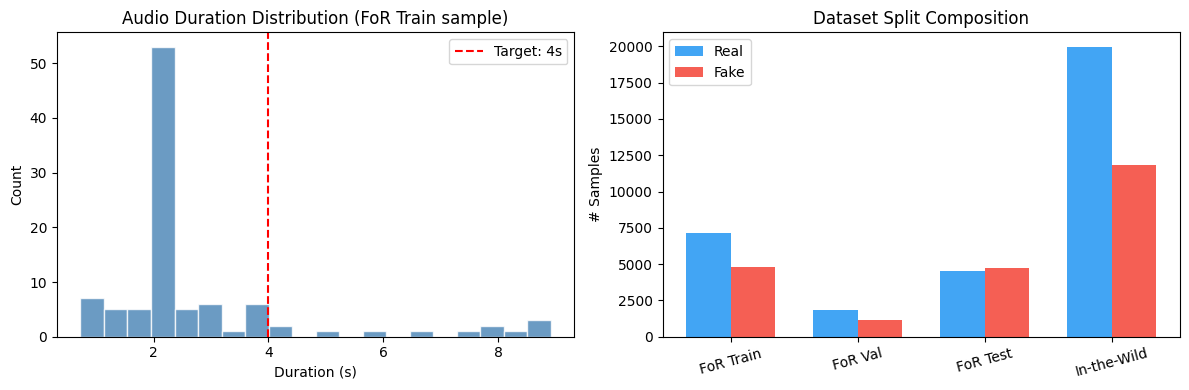

Saved dataset_overview.png


In [20]:
# ─── Duration distribution of a sample ───
sample_paths = train_df.sample(min(200, len(train_df)), random_state=42)["filepath"].tolist()
durations = []
for p in sample_paths[:100]:  # fast subset
    try:
        d = librosa.get_duration(path=p)
        durations.append(d)
    except:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(durations, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(DURATION, color='red', linestyle='--', label=f'Target: {DURATION}s')
axes[0].set_title("Audio Duration Distribution (FoR Train sample)")
axes[0].set_xlabel("Duration (s)"); axes[0].set_ylabel("Count"); axes[0].legend()

# Dataset composition
names  = ["FoR Train", "FoR Val", "FoR Test", "In-the-Wild"]
totals = [len(train_df), len(val_df), len(for_test_df), len(itw_df)]
reals  = [(df.label==0).sum() for df in [train_df, val_df, for_test_df, itw_df]]
fakes  = [(df.label==1).sum() for df in [train_df, val_df, for_test_df, itw_df]]
x = np.arange(len(names))
w = 0.35
axes[1].bar(x - w/2, reals, w, label='Real', color='#2196F3', alpha=0.85)
axes[1].bar(x + w/2, fakes, w, label='Fake', color='#F44336', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=15)
axes[1].set_title("Dataset Split Composition"); axes[1].set_ylabel("# Samples")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dataset_overview.png", dpi=150)
plt.show()
print("Saved dataset_overview.png")


## 4. Multi-Resolution Spectrogram Visualization

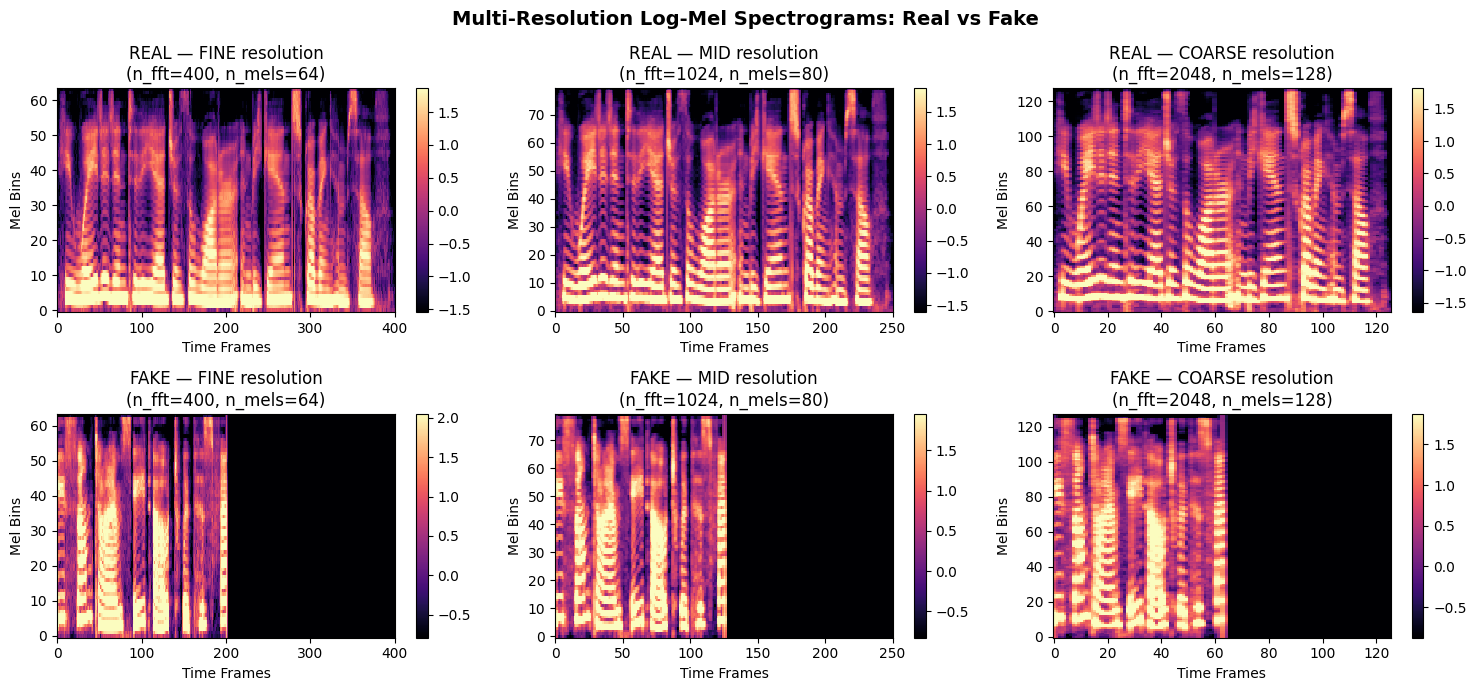


Spectrogram shapes:
  fine    : (64, 401)  (n_fft=400, hop=160)
  mid     : (80, 251)  (n_fft=1024, hop=256)
  coarse  : (128, 126)  (n_fft=2048, hop=512)


In [21]:
def load_audio(path, sr=SR, num_samples=NUM_SAMPLES, random_crop=False):
    """Load mono audio and return fixed-length waveform.

    random_crop=True is used for training augmentation;
    random_crop=False (center crop) is used for eval/inference stability.
    """
    try:
        y, _ = librosa.load(path, sr=sr, mono=True, res_type='kaiser_fast')
        if len(y) > num_samples:
            if random_crop:
                start = random.randint(0, len(y) - num_samples)
            else:
                start = max((len(y) - num_samples) // 2, 0)
            y = y[start:start + num_samples]
        elif len(y) < num_samples:
            y = np.pad(y, (0, num_samples - len(y)))
        mx = np.max(np.abs(y))
        if mx > 0:
            y = y / mx
        return y.astype(np.float32)
    except Exception:
        return np.zeros(num_samples, dtype=np.float32)


def compute_logmel(y, cfg, sr=SR):
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=cfg["n_fft"],
        hop_length=cfg["hop_length"], n_mels=cfg["n_mels"], power=2.0)
    mel = np.maximum(mel, 1e-10)
    lm = librosa.power_to_db(mel, ref=np.max)
    lm = np.nan_to_num(lm, nan=0.0, posinf=0.0, neginf=-80.0)

    std = lm.std()
    if std < 1e-6:
        return lm.astype(np.float32)
    return ((lm - lm.mean()) / (std + 1e-6)).astype(np.float32)


def _imshow_spec(ax, lm, title):
    vals = lm[np.isfinite(lm)]
    if vals.size == 0:
        vmin, vmax = -1.0, 1.0
    else:
        vmin, vmax = np.percentile(vals, [5, 95])
        if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or abs(vmax - vmin) < 1e-6:
            vmin, vmax = float(vals.min()), float(vals.max() + 1e-6)

    im = ax.imshow(
        lm,
        aspect='auto',
        origin='lower',
        cmap='magma',
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel('Time Frames')
    ax.set_ylabel('Mel Bins')
    return im


# ─── Plot real vs fake across 3 resolutions ───
real_path = train_df[train_df.label == 0].iloc[0]["filepath"]
fake_path = train_df[train_df.label == 1].iloc[0]["filepath"]
real_y = load_audio(real_path, random_crop=False)
fake_y = load_audio(fake_path, random_crop=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for col, cfg in enumerate(MEL_CONFIGS):
    for row, (y, title) in enumerate([(real_y, 'REAL'), (fake_y, 'FAKE')]):
        lm = compute_logmel(y, cfg)
        im = _imshow_spec(
            axes[row, col],
            lm,
            f"{title} — {cfg['name'].upper()} resolution\n(n_fft={cfg['n_fft']}, n_mels={cfg['n_mels']})",
        )
        plt.colorbar(im, ax=axes[row, col])

plt.suptitle('Multi-Resolution Log-Mel Spectrograms: Real vs Fake', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/multiresolution_spectrograms.png", dpi=150)
plt.show()
print(f"\nSpectrogram shapes:")
for cfg in MEL_CONFIGS:
    lm = compute_logmel(real_y, cfg)
    print(f"  {cfg['name']:8s}: {lm.shape}  (n_fft={cfg['n_fft']}, hop={cfg['hop_length']})")


## 5. Data Augmentation for Generalization

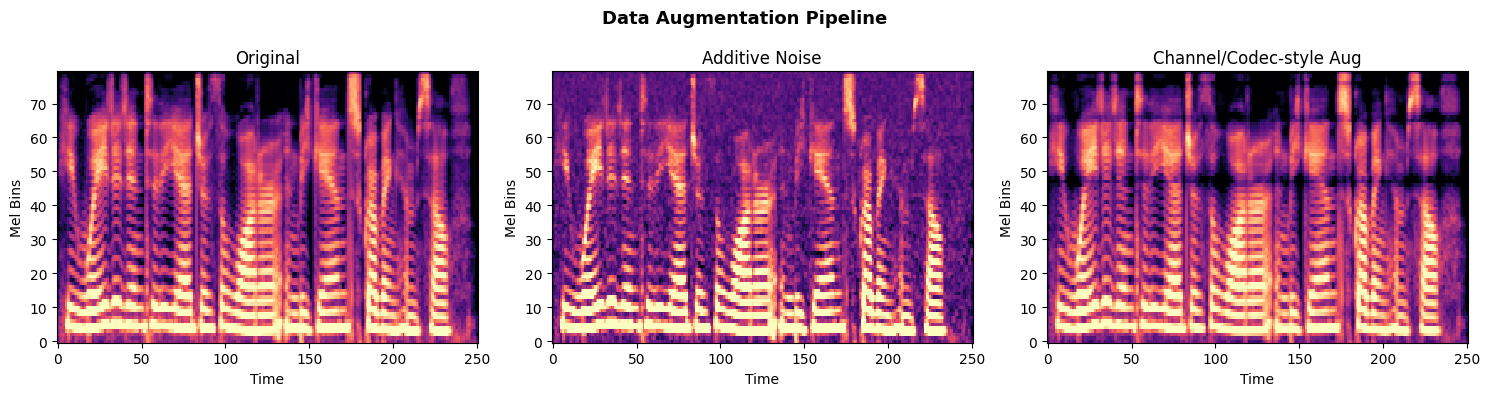

In [22]:
def spec_augment(logmel, freq_mask_param=15, time_mask_param=30,
                 n_freq_masks=2, n_time_masks=2):
    """SpecAugment for generalization (Park et al. 2019)."""
    mel = logmel.copy()
    n_mels, T = mel.shape
    for _ in range(n_freq_masks):
        f = random.randint(1, max(2, freq_mask_param))
        f0 = random.randint(0, max(0, n_mels - f))
        mel[f0:f0+f, :] = 0.0
    for _ in range(n_time_masks):
        t = random.randint(1, max(2, time_mask_param))
        t0 = random.randint(0, max(0, T - t))
        mel[:, t0:t0+t] = 0.0
    return mel


def _fix_length(y, target_len=NUM_SAMPLES):
    if len(y) > target_len:
        y = y[:target_len]
    elif len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    return y.astype(np.float32)


def _safe_resample(y, orig_sr, target_sr):
    """Resample with robust fallbacks (no hard dependency on resampy)."""
    if int(orig_sr) == int(target_sr):
        return y.astype(np.float32)
    try:
        return librosa.resample(
            y, orig_sr=orig_sr, target_sr=target_sr, res_type='soxr_hq'
        ).astype(np.float32)
    except Exception:
        try:
            return librosa.resample(y, orig_sr=orig_sr, target_sr=target_sr).astype(np.float32)
        except Exception:
            # Final fallback: linear interpolation
            n_target = max(1, int(round(len(y) * float(target_sr) / float(orig_sr))))
            if len(y) <= 1 or n_target <= 1:
                return y.astype(np.float32)
            x_old = np.linspace(0.0, 1.0, num=len(y), endpoint=False, dtype=np.float32)
            x_new = np.linspace(0.0, 1.0, num=n_target, endpoint=False, dtype=np.float32)
            return np.interp(x_new, x_old, y).astype(np.float32)


def additive_noise(y, snr_db_range=(12, 35)):
    """Add Gaussian noise to raw waveform for robustness."""
    snr_db = random.uniform(*snr_db_range)
    signal_power = np.mean(y**2) + 1e-10
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.randn(*y.shape).astype(np.float32) * np.sqrt(noise_power)
    return np.clip(y + noise, -1.0, 1.0)


def time_stretch_aug(y, rate_range=(0.9, 1.1)):
    """Randomly time-stretch audio for temporal variability."""
    rate = random.uniform(*rate_range)
    y_stretched = librosa.effects.time_stretch(y, rate=rate)
    return _fix_length(y_stretched)


def codec_sim_aug(y):
    """
    Lightweight codec simulation (MP3/AAC/telephony-like):
    bandwidth limiting + low-bit quantization + packet-drop style gaps.
    """
    out = y.astype(np.float32)

    # Bandwidth narrowing via downsample-resample.
    if random.random() < 0.9:
        target_sr = random.choice([8000, 12000, 16000])
        if target_sr != SR:
            out = _safe_resample(out, orig_sr=SR, target_sr=target_sr)
            out = _safe_resample(out, orig_sr=target_sr, target_sr=SR)
            out = _fix_length(out)

    # Quantization (coarse bit depth).
    if random.random() < 0.8:
        bits = random.choice([6, 8, 10, 12])
        q = float((2 ** bits) - 1)
        out = np.round(((np.clip(out, -1.0, 1.0) + 1.0) * 0.5) * q) / q
        out = (out * 2.0 - 1.0).astype(np.float32)

    # Packet-loss/dropout style short gaps.
    if random.random() < 0.35:
        n_drops = random.randint(1, 4)
        max_w = max(8, SR // 160)  # up to ~100 ms
        for _ in range(n_drops):
            w = random.randint(max_w // 4, max_w)
            s = random.randint(0, max(0, len(out) - w))
            out[s:s + w] *= random.uniform(0.0, 0.25)

    return np.clip(_fix_length(out), -1.0, 1.0)


def rir_reverb_aug(y):
    """Synthetic RIR convolution for room/environment mismatch."""
    out = y.astype(np.float32)
    L = random.randint(int(0.03 * SR), int(0.18 * SR))  # ~30 to 180 ms
    t = np.arange(L, dtype=np.float32) / float(SR)
    rt60 = random.uniform(0.15, 0.70)

    decay = np.exp(-6.91 * t / max(rt60, 1e-3)).astype(np.float32)
    ir = np.random.randn(L).astype(np.float32) * decay
    ir[0] += 1.0
    if random.random() < 0.6:
        early = random.choice([16, 24, 32])
        ir[:early] += np.linspace(0.8, 0.1, early, dtype=np.float32)
    ir /= (np.sum(np.abs(ir)) + 1e-6)

    out = np.convolve(out, ir, mode='full')[:len(out)].astype(np.float32)
    return np.clip(_fix_length(out), -1.0, 1.0)


def mic_filter_aug(y):
    """Microphone response simulation: emphasis + bandwidth + mild clipping."""
    out = y.astype(np.float32)

    # High-pass style pre-emphasis.
    if random.random() < 0.8:
        a = random.uniform(0.92, 0.98)
        out[1:] = out[1:] - a * out[:-1]

    # Low-pass style smoothing.
    if random.random() < 0.8:
        k = random.choice([3, 5, 7, 9])
        ker = np.ones(k, dtype=np.float32) / k
        out = np.convolve(out, ker, mode='same').astype(np.float32)

    # Dynamic range distortion.
    if random.random() < 0.5:
        gamma = random.uniform(0.75, 1.35)
        out = np.sign(out) * np.power(np.abs(out), gamma)
    if random.random() < 0.35:
        clip_v = random.uniform(0.65, 0.90)
        out = np.clip(out, -clip_v, clip_v) / clip_v

    return np.clip(out, -1.0, 1.0)


def random_channel_aug(y):
    """RawBoost-like channel augmentation pipeline."""
    out = y.astype(np.float32)

    if random.random() < P_MIC_AUG:
        out = mic_filter_aug(out)
    if random.random() < P_CODEC_AUG:
        out = codec_sim_aug(out)
    if random.random() < P_RIR_AUG:
        out = rir_reverb_aug(out)

    return np.clip(_fix_length(out), -1.0, 1.0)


# ─── Visualize augmentations ───
y_orig = load_audio(real_path)
y_noise = additive_noise(y_orig.copy())
y_codec = codec_sim_aug(y_orig.copy())
y_chan = random_channel_aug(y_orig.copy())
lm_orig = compute_logmel(y_orig, MEL_CONFIGS[1])
lm_noise = compute_logmel(y_noise, MEL_CONFIGS[1])
lm_codec = compute_logmel(y_codec, MEL_CONFIGS[1])
lm_chan = compute_logmel(y_chan, MEL_CONFIGS[1])

vals = lm_orig[np.isfinite(lm_orig)]
if vals.size > 0:
    vmin, vmax = np.percentile(vals, [5, 95])
else:
    vmin, vmax = -1.0, 1.0

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, lm, t in zip(
    axes,
    [lm_orig, lm_noise, lm_codec, lm_chan],
    ['Original', 'Additive Noise', 'Codec Sim', 'RawBoost-style Channel']
):
    ax.imshow(
        lm,
        aspect='auto',
        origin='lower',
        cmap='magma',
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(t)
    ax.set_xlabel('Time')
    ax.set_ylabel('Mel Bins')
plt.suptitle('Data Augmentation Pipeline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/augmentation_examples.png", dpi=150)
plt.show()


## 6. Dataset & DataLoaders

In [23]:
from torch.utils.data import WeightedRandomSampler

class FastAudioDataset(Dataset):
    """
    Loads waveforms only. Log-mel extraction is moved to batched GPU code
    to avoid expensive per-sample librosa feature extraction in workers.
    """
    def __init__(self, df, augment=False):
        self.paths = df['filepath'].tolist()
        self.labels = df['label'].astype(np.float32).to_numpy()
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        lbl = float(self.labels[idx])
        y = load_audio(self.paths[idx], random_crop=self.augment)

        if self.augment:
            # Slightly stronger augmentation on fake class to reduce bias toward real.
            p_boost = 1.20 if lbl > 0.5 else 1.00

            if random.random() < min(P_ADD_NOISE * p_boost, 0.90):
                y = additive_noise(y)
            if random.random() < min(P_MIC_AUG * p_boost, 0.90):
                y = mic_filter_aug(y)
            if random.random() < min(P_CODEC_AUG * p_boost, 0.90):
                y = codec_sim_aug(y)
            if random.random() < min(P_RIR_AUG * p_boost, 0.85):
                y = rir_reverb_aug(y)
            if random.random() < min(0.25 * p_boost, 0.70):
                y = random_channel_aug(y)
            if random.random() < 0.20:
                y = time_stretch_aug(y)
            if random.random() < 0.30:
                gain = random.uniform(0.6, 1.4)
                y = np.clip(y * gain, -1.0, 1.0)
            if random.random() < 0.25:
                shift = random.randint(-SR // 8, SR // 8)
                y = np.roll(y, shift)
            if random.random() < 0.10:
                y = -y

        return torch.from_numpy(y), torch.tensor(lbl, dtype=torch.float32)


# ─── Batched multi-resolution log-mel on GPU/torch ───
MEL_T_TARGETS = [math.ceil(NUM_SAMPLES / cfg['hop_length']) + 1 for cfg in MEL_CONFIGS]
_MEL_FB_CACHE = {}
_WIN_CACHE = {}


def _get_window(n_fft, device):
    key = (n_fft, str(device))
    if key not in _WIN_CACHE:
        _WIN_CACHE[key] = torch.hann_window(n_fft, device=device)
    return _WIN_CACHE[key]


def _get_mel_filter(cfg, device):
    key = (cfg['n_fft'], cfg['n_mels'], SR, str(device))
    if key not in _MEL_FB_CACHE:
        fb = librosa.filters.mel(sr=SR, n_fft=cfg['n_fft'], n_mels=cfg['n_mels']).astype(np.float32)
        _MEL_FB_CACHE[key] = torch.from_numpy(fb).to(device)
    return _MEL_FB_CACHE[key]


def _apply_light_specaugment(logmel):
    """Cheap in-place masking to improve OOD robustness."""
    B, M, T = logmel.shape
    max_f = max(2, M // 12)
    max_t = max(2, T // 16)
    for b in range(B):
        if random.random() < 0.5:
            f = random.randint(1, max_f)
            f0 = random.randint(0, max(0, M - f))
            logmel[b, f0:f0+f, :] = 0.0
        if random.random() < 0.5:
            t = random.randint(1, max_t)
            t0 = random.randint(0, max(0, T - t))
            logmel[b, :, t0:t0+t] = 0.0
    return logmel


def make_multires_logmels(waveforms, train_mode=False):
    """
    waveforms: (B, NUM_SAMPLES) float32 in [-1,1]
    returns list of K tensors: (B,1,n_mels,T)
    """
    mels_out = []
    for cfg, t_target in zip(MEL_CONFIGS, MEL_T_TARGETS):
        n_fft = cfg['n_fft']
        hop = cfg['hop_length']

        spec = torch.stft(
            waveforms,
            n_fft=n_fft,
            hop_length=hop,
            win_length=n_fft,
            window=_get_window(n_fft, waveforms.device),
            center=True,
            return_complex=True,
        )
        power = spec.real.pow(2) + spec.imag.pow(2)
        mel_fb = _get_mel_filter(cfg, waveforms.device)
        mel = torch.einsum('mf,bft->bmt', mel_fb, power)

        logmel = torch.log(mel + 1e-6)
        mean = logmel.mean(dim=(1, 2), keepdim=True)
        std = logmel.std(dim=(1, 2), keepdim=True).clamp_min(1e-5)
        logmel = (logmel - mean) / std

        if train_mode:
            logmel = _apply_light_specaugment(logmel)

        if logmel.shape[-1] < t_target:
            logmel = F.pad(logmel, (0, t_target - logmel.shape[-1]))
        else:
            logmel = logmel[..., :t_target]

        mels_out.append(logmel.unsqueeze(1).contiguous())

    return mels_out


def make_loaders(train_df, val_df, for_test_df, itw_df):
    train_ds = FastAudioDataset(train_df, augment=True)
    val_ds = FastAudioDataset(val_df, augment=False)
    for_test_ds = FastAudioDataset(for_test_df, augment=False)
    itw_ds = FastAudioDataset(itw_df, augment=False)

    kw = dict(
        num_workers=NUM_WORKERS,
        pin_memory=False,
        persistent_workers=(NUM_WORKERS > 0),
    )
    if NUM_WORKERS > 0:
        kw['prefetch_factor'] = PREFETCH_FACTOR

    sampler = None
    if USE_BALANCED_SAMPLER and len(train_df) > 0:
        cls_counts = train_df['label'].value_counts().to_dict()
        w_real = 1.0 / max(cls_counts.get(0, 1), 1)
        w_fake = 1.0 / max(cls_counts.get(1, 1), 1)
        sample_w = np.where(train_df['label'].to_numpy() == 1, w_fake, w_real).astype(np.float64)
        sampler = WeightedRandomSampler(
            weights=torch.from_numpy(sample_w),
            num_samples=len(sample_w),
            replacement=True,
            generator=torch.Generator().manual_seed(SEED),
        )
        print(f"Balanced sampler enabled | real={cls_counts.get(0,0)} fake={cls_counts.get(1,0)}")

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=(sampler is None),
        sampler=sampler,
        drop_last=True,
        **kw,
    )
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False, drop_last=False, **kw)
    for_test_loader = DataLoader(for_test_ds, batch_size=BATCH_SIZE * 2, shuffle=False, drop_last=False, **kw)
    itw_loader = DataLoader(itw_ds, batch_size=BATCH_SIZE * 2, shuffle=False, drop_last=False, **kw)
    return train_loader, val_loader, for_test_loader, itw_loader


train_loader, val_loader, for_test_loader, itw_loader = make_loaders(
    train_df, val_df, for_test_df, itw_df)

# Sanity check
batch_wavs, batch_labels = next(iter(train_loader))
print('Batch check:')
print(f"  Waveforms: {tuple(batch_wavs.shape)}")
print(f"  Labels shape: {batch_labels.shape}  sample={batch_labels[:6].tolist()}")

with torch.no_grad():
    mel_test = make_multires_logmels(batch_wavs[:2].to(device, non_blocking=True), train_mode=False)
for i, (m, cfg) in enumerate(zip(mel_test, MEL_CONFIGS)):
    print(f"  Scale {i} ({cfg['name']:6s}): {tuple(m.shape)}  n_mels={cfg['n_mels']}")


Balanced sampler enabled | real=7176 fake=4824
Batch check:
  Waveforms: (16, 64000)
  Labels shape: torch.Size([16])  sample=[1.0, 0.0, 1.0, 0.0, 1.0, 1.0]
  Scale 0 (fine  ): (2, 1, 64, 401)  n_mels=64
  Scale 1 (mid   ): (2, 1, 80, 251)  n_mels=80
  Scale 2 (coarse): (2, 1, 128, 126)  n_mels=128


## 7. Model: HM-Conformer with Multi-Scale Cross-Attention

**Architecture novelty:** We adapt HM-Conformer (Shin et al. 2023) by adding:
1. A dedicated lightweight encoder per spectral scale (Shahriar 2026)
2. Cross-scale attention fusing embeddings across resolutions
3. Hierarchical pooling within each Conformer branch
4. Multi-level CLS token aggregation across encoder stages

In [24]:
# ─────────────────────────────────────────
# Building blocks
# ─────────────────────────────────────────

def mixstyle_1d(x, p=MIXSTYLE_P, alpha=MIXSTYLE_A, eps=1e-6):
    """MixStyle over temporal features (B,T,D) for domain generalization."""
    if (not torch.is_grad_enabled()) or (not x.requires_grad) or x.size(0) < 2:
        return x
    if random.random() > p:
        return x

    mu = x.mean(dim=1, keepdim=True)
    var = x.var(dim=1, keepdim=True, unbiased=False)
    sig = (var + eps).sqrt()
    x_norm = (x - mu) / sig

    perm = torch.randperm(x.size(0), device=x.device)
    mu2, sig2 = mu[perm], sig[perm]

    lam = torch.distributions.Beta(alpha, alpha).sample((x.size(0), 1, 1)).to(x.device)
    mu_mix = lam * mu + (1.0 - lam) * mu2
    sig_mix = lam * sig + (1.0 - lam) * sig2
    return x_norm * sig_mix + mu_mix


def sinusoidal_timestep_embedding(t, dim):
    """Sinusoidal embedding for normalized diffusion timestep t in [0,1]."""
    half = dim // 2
    if half <= 0:
        return t.unsqueeze(-1)
    freqs = torch.exp(
        torch.arange(half, device=t.device, dtype=t.dtype) *
        (-math.log(10000.0) / max(half - 1, 1))
    )
    args = t.unsqueeze(-1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


class FeedForward(nn.Module):
    def __init__(self, d, expansion=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d * expansion), nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d * expansion, d), nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class ConvModule(nn.Module):
    def __init__(self, d, ks=15):
        super().__init__()
        self.norm = nn.LayerNorm(d)
        self.pw1 = nn.Conv1d(d, d * 2, 1)
        self.glu = nn.GLU(dim=1)
        self.dw = nn.Conv1d(d, d, ks, padding=ks // 2, groups=d)
        self.bn = nn.BatchNorm1d(d)
        self.pw2 = nn.Conv1d(d, d, 1)
        self.drop = nn.Dropout(0.1)

    def forward(self, x):
        r = self.norm(x).transpose(1, 2)
        r = self.glu(self.pw1(r))
        r = F.silu(self.bn(self.dw(r)))
        return self.drop(self.pw2(r)).transpose(1, 2)


class ConformerBlock(nn.Module):
    def __init__(self, d, heads=4, ks=15, dropout=0.1):
        super().__init__()
        self.ff1 = FeedForward(d, dropout=dropout)
        self.attn = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.norm_a = nn.LayerNorm(d)
        self.conv = ConvModule(d, ks)
        self.ff2 = FeedForward(d, dropout=dropout)
        self.norm = nn.LayerNorm(d)

    def forward(self, x):
        x = x + 0.5 * self.ff1(x)
        a, _ = self.attn(self.norm_a(x), self.norm_a(x), self.norm_a(x), need_weights=False)
        x = x + a
        x = x + self.conv(x)
        x = x + 0.5 * self.ff2(x)
        return self.norm(x)


def _resize_time(x, target_t):
    """Resize sequence length with linear interpolation on temporal axis."""
    if x.size(1) == target_t:
        return x
    xt = x.transpose(1, 2)
    xt = F.interpolate(xt, size=target_t, mode='linear', align_corners=False)
    return xt.transpose(1, 2)


class ScaleEncoder(nn.Module):
    """Lightweight CNN encoder for one spectral scale."""
    def __init__(self, n_mels, d_out):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=(2, 1), padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=(2, 1), padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        )
        freq_out = math.ceil(math.ceil(n_mels / 2) / 2)
        self.proj = nn.Linear(64 * freq_out, d_out)

    def forward(self, x):
        h = self.cnn(x)  # (B,64,F',T)
        B, C, Fm, T = h.shape
        h = h.permute(0, 3, 1, 2).reshape(B, T, C * Fm)
        return self.proj(h)  # (B,T,d_out)


class CrossScaleAttentionFusion(nn.Module):
    """Cross-scale attention: each scale attends to all other scales."""
    def __init__(self, d, heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d)
        self.proj = nn.Linear(d, d)

    def forward(self, zs):
        Z = torch.stack(zs, dim=1)  # (B,K,d)
        attn_out, attn_w = self.attn(self.norm(Z), self.norm(Z), self.norm(Z))
        fused = Z + attn_out
        return self.proj(fused.mean(dim=1)), attn_w


class CrossScaleInteractor(nn.Module):
    """
    Interactive cross-scale attention at sequence level.
    Each scale attends to other scales after temporal alignment.
    """
    def __init__(self, d, n_scales, heads=4, dropout=0.1):
        super().__init__()
        self.n_scales = n_scales
        self.q_norms = nn.ModuleList([nn.LayerNorm(d) for _ in range(n_scales)])
        self.kv_norms = nn.ModuleList([nn.LayerNorm(d) for _ in range(n_scales)])
        self.out_projs = nn.ModuleList([
            nn.Sequential(nn.Linear(d, d), nn.Dropout(dropout))
            for _ in range(n_scales)
        ])
        self.cross_attn = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.gates = nn.Parameter(torch.full((n_scales,), 0.20))

    def forward(self, seqs):
        mixed = []
        for i, x_i in enumerate(seqs):
            q = self.q_norms[i](x_i)
            msgs = []
            for j, x_j in enumerate(seqs):
                if i == j:
                    continue
                kv = _resize_time(x_j, q.size(1))
                kv = self.kv_norms[j](kv)
                attn_out, _ = self.cross_attn(q, kv, kv, need_weights=False)
                msgs.append(attn_out)

            if len(msgs) == 0:
                mixed.append(x_i)
                continue

            msg = torch.stack(msgs, dim=0).mean(dim=0)
            gate = torch.sigmoid(self.gates[i])
            mixed.append(x_i + gate * self.out_projs[i](msg))

        return mixed


class HMConformerXAI(nn.Module):
    """
    Diffusive HM-Conformer:
      ScaleEncoder -> latent diffusion perturbation + timestep conditioning
      -> shared Conformer blocks -> cross-scale fusion -> classifier.

    Diffusion branch adds denoising auxiliary loss for stronger OOD robustness.
    """
    def __init__(self, mel_configs=MEL_CONFIGS, d_model=D_MODEL, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.mel_configs = mel_configs
        self.use_diffusion = bool(USE_DIFFUSIVE_BRANCH)
        K = len(mel_configs)

        self.scale_encoders = nn.ModuleList([
            ScaleEncoder(cfg['n_mels'], d_model) for cfg in mel_configs
        ])

        self.conformer = nn.ModuleList([
            ConformerBlock(d_model, heads=N_HEADS, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.cross_interactors = nn.ModuleList([
            CrossScaleInteractor(d_model, K, heads=N_HEADS, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.pool_positions = {1, 3}

        self.cross_scale = CrossScaleAttentionFusion(d_model)
        self.consist_proj = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(K)])

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, 64),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(64, 1)
        )

        # Diffusion modules
        self.diff_steps = int(DIFF_STEPS)
        betas = torch.linspace(DIFF_BETA_MIN, DIFF_BETA_MAX, self.diff_steps)
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)
        self.register_buffer('diff_alpha_bars', alpha_bars)

        self.time_mlp = nn.Sequential(
            nn.Linear(d_model, d_model), nn.SiLU(), nn.Linear(d_model, d_model)
        )
        self.diff_refine = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model * 2), nn.SiLU(),
            nn.Linear(d_model * 2, d_model),
        )
        self.diff_gate = nn.Parameter(torch.tensor(0.15))
        self._last_diff_loss = torch.tensor(0.0)

        # XAI hooks
        self.gradients = {}
        self.activations = {}

    def _hook_fn(self, name):
        def hook(module, input, output):
            self.activations[name] = output.detach()
        return hook

    def register_gradcam_hooks(self):
        handle = self.conformer[-1].register_forward_hook(self._hook_fn('last_conformer'))
        return handle

    def _pool_time(self, x):
        x_t = x.transpose(1, 2)
        x_t = F.avg_pool1d(x_t, kernel_size=2, stride=2, padding=0)
        return x_t.transpose(1, 2)

    def _diffuse_latent(self, x):
        """
        Adds DDPM-style noise and timestep conditioning on latent sequence x.
        x: (B,T,D)
        """
        B = x.size(0)
        t_idx = torch.randint(0, self.diff_steps, (B,), device=x.device)
        a_bar = self.diff_alpha_bars[t_idx].view(B, 1, 1).clamp(1e-5, 0.9999)
        eps = torch.randn_like(x)
        x_noisy = a_bar.sqrt() * x + (1.0 - a_bar).sqrt() * eps

        t_norm = t_idx.float() / float(max(self.diff_steps - 1, 1))
        t_emb = sinusoidal_timestep_embedding(t_norm, x.size(-1))
        t_emb = self.time_mlp(t_emb).unsqueeze(1)
        return x_noisy, t_emb

    def forward(self, mels_list):
        xs = []
        refs = []
        diff_losses = []

        for mel, encoder in zip(mels_list, self.scale_encoders):
            x_clean = encoder(mel)  # (B,T,D)

            if self.training:
                x_clean = mixstyle_1d(x_clean)

            if self.training and self.use_diffusion:
                x, t_emb = self._diffuse_latent(x_clean)
                x = x + torch.tanh(self.diff_gate) * t_emb
                x_ref = x_clean
            else:
                x = x_clean
                x_ref = None

            xs.append(x)
            refs.append(x_ref)

        # Multi-stage interactive fusion: exchange cross-scale cues per block.
        for i, block in enumerate(self.conformer):
            xs = [block(x) for x in xs]

            if i in self.pool_positions:
                xs = [self._pool_time(x) for x in xs]
                refs = [self._pool_time(r) if r is not None else None for r in refs]

            xs = self.cross_interactors[i](xs)

        embeddings = [x.mean(dim=1) for x in xs]

        for x, x_ref in zip(xs, refs):
            if x_ref is None:
                continue
            x_ref = _resize_time(x_ref, x.size(1))
            denoised = self.diff_refine(x)
            diff_losses.append(F.smooth_l1_loss(denoised, x_ref.detach()))

        fused, attn_weights = self.cross_scale(embeddings)
        self._last_attn_weights = attn_weights

        if len(diff_losses) > 0:
            self._last_diff_loss = torch.stack(diff_losses).mean()
        else:
            self._last_diff_loss = fused.new_zeros(())

        logits = self.classifier(fused).squeeze(-1)
        consist_embs = [F.normalize(self.consist_proj[k](e), dim=-1) for k, e in enumerate(embeddings)]
        return logits, consist_embs

    def consistency_loss(self, consist_embs):
        K = len(consist_embs)
        loss = 0
        pairs = 0
        for i in range(K):
            for j in range(i + 1, K):
                loss = loss + ((consist_embs[i] - consist_embs[j]) ** 2).sum(dim=-1).mean()
                pairs += 1
        return loss / max(pairs, 1)


# ─── Build & test model ───
if torch.cuda.is_available() and FORCE_SINGLE_GPU:
    torch.cuda.set_device(0)

model = HMConformerXAI().to(device)
if torch.cuda.device_count() > 1 and not FORCE_SINGLE_GPU:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
elif torch.cuda.device_count() > 1 and FORCE_SINGLE_GPU:
    print('Using single GPU (GPU:0) for memory stability')

# Test forward pass
test_wavs = batch_wavs[:2].to(device, non_blocking=True)
test_mels = make_multires_logmels(test_wavs, train_mode=False)
with torch.no_grad():
    logits, cembs = model(test_mels)
print(f"✓ Forward pass OK  |  logits: {logits.shape}  |  embs: {[e.shape for e in cembs]}")
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters: {n_params:,}")


Using single GPU (GPU:0) for memory stability
✓ Forward pass OK  |  logits: torch.Size([2])  |  embs: [torch.Size([2, 96]), torch.Size([2, 96]), torch.Size([2, 96])]
  Trainable parameters: 1,058,338


## 8. Training Infrastructure

In [25]:
def compute_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    d = np.abs(fnr - fpr)
    idx = np.nanargmin(d)
    return float((fpr[idx] + fnr[idx]) / 2)


def label_smooth(labels, s=0.03):
    return labels * (1 - s) + 0.5 * s


def get_cosine_schedule(optimizer, warmup, total):
    def lr_fn(step):
        if step < warmup:
            return step / max(1, warmup)
        p = (step - warmup) / max(1, total - warmup)
        return max(0.0, 0.5 * (1 + math.cos(math.pi * p)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_fn)


class FocalBCEWithLogits(nn.Module):
    """Focal BCE with optional pos_weight for imbalance handling."""
    def __init__(self, gamma=1.5, alpha=0.45, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.register_buffer('pos_weight_buf', pos_weight if pos_weight is not None else None)

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction='none',
            pos_weight=self.pos_weight_buf,
        )
        p = torch.sigmoid(logits)
        pt = targets * p + (1.0 - targets) * (1.0 - p)
        focal = (1.0 - pt).pow(self.gamma)

        if self.alpha is not None:
            alpha_t = targets * self.alpha + (1.0 - targets) * (1.0 - self.alpha)
            focal = focal * alpha_t

        return (focal * bce).mean()


def find_best_threshold(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(y_true) == 0:
        return 0.5, 0.0

    fpr, tpr, thr = roc_curve(y_true, y_score)
    fnr = 1.0 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    best_t = thr[idx]
    if not np.isfinite(best_t):
        best_t = 0.5
    best_t = float(np.clip(best_t, 0.01, 0.99))
    y_p = (y_score >= best_t).astype(int)
    return best_t, float(f1_score(y_true, y_p, zero_division=0))


def supervised_contrastive_loss(emb, labels, temperature=0.15):
    """
    SupCon-style loss for binary labels.
    emb: (B,D) normalized embeddings
    labels: (B,) int labels
    """
    if emb.size(0) < 2:
        return emb.new_zeros(())

    z = F.normalize(emb, dim=-1)
    sim = torch.matmul(z, z.t()) / max(float(temperature), 1e-6)

    labels = labels.view(-1, 1)
    pos_mask = torch.eq(labels, labels.t()).float().to(emb.device)
    eye = torch.eye(pos_mask.size(0), device=emb.device)
    pos_mask = pos_mask - eye

    logits_mask = 1.0 - eye
    sim = sim - sim.max(dim=1, keepdim=True).values.detach()
    exp_sim = torch.exp(sim) * logits_mask
    log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-9)

    pos_count = pos_mask.sum(dim=1)
    valid = pos_count > 0
    if valid.sum() == 0:
        return emb.new_zeros(())

    mean_log_prob_pos = (pos_mask * log_prob).sum(dim=1) / pos_count.clamp_min(1.0)
    return -mean_log_prob_pos[valid].mean()


def find_domain_threshold(
    y_true,
    y_score,
    beta=2.0,
    min_recall=0.30,
    min_precision=0.30,
    t_min=0.10,
    t_max=0.90,
):
    """Constraint-aware threshold search for target-domain calibration."""
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(y_true) == 0:
        return 0.5, {"objective": 0.0, "recall": 0.0, "precision": 0.0}

    beta2 = beta * beta
    best_t = 0.5
    best_obj = -1.0
    best_rec = 0.0
    best_prec = 0.0

    grid = np.linspace(t_min, t_max, 161)
    for t in grid:
        y_p = (y_score >= t).astype(int)

        rec = recall_score(y_true, y_p, zero_division=0)
        prec = precision_score(y_true, y_p, zero_division=0)
        if rec < min_recall or prec < min_precision:
            continue

        denom = (beta2 * prec + rec)
        fbeta = ((1.0 + beta2) * prec * rec / denom) if denom > 0 else 0.0

        rec_neg = recall_score(1 - y_true, 1 - y_p, zero_division=0)
        bacc = 0.5 * (rec + rec_neg)
        obj = 0.75 * fbeta + 0.25 * bacc

        if obj > best_obj:
            best_obj = float(obj)
            best_t = float(t)
            best_rec = float(rec)
            best_prec = float(prec)

    if best_obj < 0:
        # Fallback: balanced accuracy maximization (still bounded threshold range)
        for t in grid:
            y_p = (y_score >= t).astype(int)
            rec = recall_score(y_true, y_p, zero_division=0)
            prec = precision_score(y_true, y_p, zero_division=0)
            rec_neg = recall_score(1 - y_true, 1 - y_p, zero_division=0)
            bacc = 0.5 * (rec + rec_neg)
            if bacc > best_obj:
                best_obj = float(bacc)
                best_t = float(t)
                best_rec = float(rec)
                best_prec = float(prec)

    return best_t, {"objective": best_obj, "recall": best_rec, "precision": best_prec}


def train_one_epoch(
    model,
    loader,
    optimizer,
    scheduler,
    scaler,
    criterion,
    lambda_c=0.1,
    lambda_d=LAMBDA_DIFF,
    lambda_s=LAMBDA_SUPCON,
    supcon_temp=SUPCON_TEMPERATURE,
    max_steps=None,
):
    model.train()
    total_loss = 0.0
    amp_enabled = (device.type == 'cuda')
    n_batches = len(loader) if max_steps is None else min(len(loader), max_steps)
    steps_done = 0

    for step, (waveforms, labels) in enumerate(loader, 1):
        waveforms = waveforms.to(device, non_blocking=True)
        labels_raw = labels.to(device, non_blocking=True)
        labels_sm = label_smooth(labels_raw)
        mels_list = make_multires_logmels(waveforms, train_mode=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=device.type, enabled=amp_enabled):
            logits, cembs = model(mels_list)
            cls_loss = criterion(logits, labels_sm)

            m = model.module if hasattr(model, 'module') else model
            if cembs[0].shape[0] > 1:
                c_loss = m.consistency_loss(cembs)
            else:
                c_loss = torch.tensor(0.0, device=device)

            d_loss = getattr(m, '_last_diff_loss', torch.tensor(0.0, device=device))
            if not torch.is_tensor(d_loss):
                d_loss = torch.tensor(float(d_loss), device=device)

            if USE_SUPCON_LOSS and cembs[0].shape[0] > 2:
                fused_emb = torch.stack(cembs, dim=1).mean(dim=1)
                supcon_loss = supervised_contrastive_loss(
                    fused_emb,
                    (labels_raw >= 0.5).long(),
                    temperature=supcon_temp,
                )
            else:
                supcon_loss = torch.tensor(0.0, device=device)

            loss = cls_loss + lambda_c * c_loss + lambda_d * d_loss + lambda_s * supcon_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.detach().float().item()
        steps_done += 1

        if step % 50 == 0 or step == n_batches:
            print(f"  step {step}/{n_batches} | avg loss {total_loss / max(steps_done, 1):.4f}")

        if step % 25 == 0:
            del mels_list, waveforms, labels_raw, labels_sm, logits, cembs, cls_loss, c_loss, d_loss, supcon_loss, loss
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if max_steps is not None and step >= max_steps:
            break

    return total_loss / max(steps_done, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, desc='', max_steps=None, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_scores, all_labels = [], []
    amp_enabled = (device.type == 'cuda')
    n_batches = len(loader) if max_steps is None else min(len(loader), max_steps)
    steps_done = 0

    for step, (waveforms, labels) in enumerate(loader, 1):
        waveforms = waveforms.to(device, non_blocking=True)
        labels_d = labels.to(device, non_blocking=True)
        mels_list = make_multires_logmels(waveforms, train_mode=False)

        with autocast(device_type=device.type, enabled=amp_enabled):
            logits, _ = model(mels_list)
            loss = criterion(logits, label_smooth(labels_d))

        total_loss += loss.detach().float().item()
        all_scores.extend(torch.sigmoid(logits).cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())
        steps_done += 1

        if step % 50 == 0:
            del mels_list, waveforms, labels_d, logits, loss
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if max_steps is not None and step >= max_steps:
            break

    y_t = np.array(all_labels)
    y_s = np.array(all_scores)
    y_p = (y_s >= threshold).astype(int)
    return dict(
        loss=total_loss / max(steps_done, 1),
        EER=compute_eer(y_t, y_s),
        AUC=roc_auc_score(y_t, y_s),
        AP=average_precision_score(y_t, y_s),
        F1=f1_score(y_t, y_p, zero_division=0),
        Acc=accuracy_score(y_t, y_p),
        Prec=precision_score(y_t, y_p, zero_division=0),
        Rec=recall_score(y_t, y_p, zero_division=0),
        y_true=y_t,
        y_score=y_s,
        threshold=float(threshold),
    )


@torch.no_grad()
def evaluate_tta(
    model,
    loader,
    criterion,
    threshold=0.5,
    tta_shifts=(0,),
    max_steps=None,
):
    """Inference with waveform shift-TTA. Scores are averaged across shifts."""
    model.eval()
    total_loss = 0.0
    all_scores, all_labels = [], []
    amp_enabled = (device.type == 'cuda')
    n_batches = len(loader) if max_steps is None else min(len(loader), max_steps)
    steps_done = 0

    for step, (waveforms, labels) in enumerate(loader, 1):
        waveforms = waveforms.to(device, non_blocking=True)
        labels_d = labels.to(device, non_blocking=True)

        score_sum = None
        first_logits = None
        for sh in tta_shifts:
            wf = waveforms if int(sh) == 0 else torch.roll(waveforms, shifts=int(sh), dims=1)
            mels_list = make_multires_logmels(wf, train_mode=False)
            with autocast(device_type=device.type, enabled=amp_enabled):
                logits, _ = model(mels_list)
            if first_logits is None:
                first_logits = logits
            probs = torch.sigmoid(logits)
            score_sum = probs if score_sum is None else (score_sum + probs)

        avg_scores = score_sum / max(len(tta_shifts), 1)
        with autocast(device_type=device.type, enabled=amp_enabled):
            loss = criterion(first_logits, label_smooth(labels_d))

        total_loss += loss.detach().float().item()
        all_scores.extend(avg_scores.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())
        steps_done += 1

        if step % 50 == 0:
            del waveforms, labels_d, first_logits, score_sum, avg_scores, loss
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if max_steps is not None and step >= max_steps:
            break

    y_t = np.array(all_labels)
    y_s = np.array(all_scores)
    y_p = (y_s >= threshold).astype(int)
    return dict(
        loss=total_loss / max(steps_done, 1),
        EER=compute_eer(y_t, y_s),
        AUC=roc_auc_score(y_t, y_s),
        AP=average_precision_score(y_t, y_s),
        F1=f1_score(y_t, y_p, zero_division=0),
        Acc=accuracy_score(y_t, y_p),
        Prec=precision_score(y_t, y_p, zero_division=0),
        Rec=recall_score(y_t, y_p, zero_division=0),
        y_true=y_t,
        y_score=y_s,
        threshold=float(threshold),
    )


# ─── Setup training ───
n_real = int((train_df.label == 0).sum())
n_fake = int((train_df.label == 1).sum())
pos_w = torch.tensor([max(n_real / max(n_fake, 1), 1e-3)], device=device)

if USE_FOCAL_LOSS:
    criterion = FocalBCEWithLogits(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, pos_weight=pos_w)
else:
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scaler = GradScaler('cuda', enabled=(device.type == 'cuda'))

effective_steps_per_epoch = min(len(train_loader), MAX_TRAIN_STEPS) if MAX_TRAIN_STEPS else len(train_loader)
total_steps = EPOCHS * max(effective_steps_per_epoch, 1)
warmup_steps = min(500, total_steps // 10)
scheduler = get_cosine_schedule(optimizer, warmup_steps, total_steps)
print(f"pos_weight={pos_w.item():.3f}  |  total_steps={total_steps}  |  warmup={warmup_steps}")
print(
    f"criterion={'FocalBCEWithLogits' if USE_FOCAL_LOSS else 'BCEWithLogitsLoss'}  | "
    f"lambda_diff={LAMBDA_DIFF} | lambda_supcon={LAMBDA_SUPCON} | "
    f"supcon={USE_SUPCON_LOSS} | diffusion={USE_DIFFUSIVE_BRANCH}"
)


pos_weight=1.488  |  total_steps=5000  |  warmup=500
criterion=FocalBCEWithLogits  | lambda_diff=0.0 | diffusion=False


## 9. Training Loop with Live Metrics

In [26]:
history = []
best_eer = 1.0
best_threshold = 0.5
patience_cnt = 0
t0 = perf_counter()

BEST_MODEL_PT = f"{CKPT_DIR}/best_model.pt"
BEST_MODEL_PTH = f"{CKPT_DIR}/best_model.pth"
BEST_CHECKPOINT_PTH = f"{CKPT_DIR}/best_checkpoint.pth"
BEST_MODEL_COPY_PTH = f"{OUTPUT_DIR}/best_model.pth"
BEST_THRESHOLD_TXT = f"{CKPT_DIR}/best_threshold.txt"

for epoch in range(1, EPOCHS + 1):
    ep_t0 = perf_counter()

    if USE_DIFFUSIVE_BRANCH:
        diff_scale = min(1.0, epoch / max(DIFF_WARMUP_EPOCHS, 1))
        lambda_d_epoch = LAMBDA_DIFF * diff_scale
    else:
        lambda_d_epoch = 0.0

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        scaler,
        criterion,
        lambda_d=lambda_d_epoch,
        max_steps=MAX_TRAIN_STEPS,
    )

    # Always collect raw val scores with threshold=0.5, then calibrate threshold.
    val_raw = evaluate(model, val_loader, criterion, max_steps=MAX_VAL_STEPS, threshold=0.5)
    val_thr, val_f1_at_thr = find_best_threshold(val_raw["y_true"], val_raw["y_score"])
    val_m = evaluate(model, val_loader, criterion, max_steps=MAX_VAL_STEPS, threshold=val_thr)

    ep_time = perf_counter() - ep_t0

    row = dict(
        epoch=epoch,
        train_loss=train_loss,
        val_loss=val_m["loss"],
        EER=val_m["EER"],
        AUC=val_m["AUC"],
        AP=val_m["AP"],
        F1=val_m["F1"],
        Acc=val_m["Acc"],
        threshold=val_thr,
        time_s=ep_time,
    )
    history.append(row)

    flag = ""
    if val_m["EER"] < best_eer:
        best_eer = val_m["EER"]
        best_threshold = float(val_thr)
        patience_cnt = 0

        m = model.module if hasattr(model, "module") else model
        state = m.state_dict()

        torch.save(state, BEST_MODEL_PT)
        torch.save(state, BEST_MODEL_PTH)
        torch.save(state, BEST_MODEL_COPY_PTH)
        torch.save(
            {
                "epoch": epoch,
                "best_val_eer": float(best_eer),
                "best_threshold": float(best_threshold),
                "model_state_dict": state,
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
            },
            BEST_CHECKPOINT_PTH,
        )
        with open(BEST_THRESHOLD_TXT, "w") as f:
            f.write(f"{best_threshold:.6f}\n")
        flag = "  ✓ best"

    print(
        f"Ep {epoch:02d}/{EPOCHS} | "
        f"loss {train_loss:.4f}→{val_m['loss']:.4f} | "
        f"EER {val_m['EER']:.4f} | AUC {val_m['AUC']:.4f} | "
        f"F1 {val_m['F1']:.4f} | Acc {val_m['Acc']:.4f} | "
        f"thr {val_thr:.3f} | ld {lambda_d_epoch:.3f} | {ep_time:.0f}s{flag}"
    )

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    patience_cnt += 1
    if patience_cnt >= PATIENCE:
        print("Early stopping triggered.")
        break

total_t = perf_counter() - t0
print(f"\n✓ Training complete in {total_t/60:.1f} min  |  Best val EER: {best_eer:.4f}")
print(f"Best threshold (val-calibrated): {best_threshold:.4f}")
print("Best model files saved:")
print(f"  {BEST_MODEL_PT}")
print(f"  {BEST_MODEL_PTH}")
print(f"  {BEST_CHECKPOINT_PTH}")
print(f"  {BEST_MODEL_COPY_PTH}")
print(f"  {BEST_THRESHOLD_TXT}")


  step 50/250 | avg loss 0.2835
  step 100/250 | avg loss 0.2225
  step 150/250 | avg loss 0.1958
  step 200/250 | avg loss 0.1810
  step 250/250 | avg loss 0.1716
Ep 01/20 | loss 0.1716→0.1096 | EER 0.1434 | AUC 0.9332 | F1 0.8293 | Acc 0.8660 | thr 0.420 | ld 0.000 | 76s  ✓ best
  step 50/250 | avg loss 0.1159
  step 100/250 | avg loss 0.1146
  step 150/250 | avg loss 0.1110
  step 200/250 | avg loss 0.1066
  step 250/250 | avg loss 0.1047
Ep 02/20 | loss 0.1047→0.0637 | EER 0.0854 | AUC 0.9767 | F1 0.9116 | Acc 0.9324 | thr 0.445 | ld 0.000 | 74s  ✓ best
  step 50/250 | avg loss 0.0888
  step 100/250 | avg loss 0.0895
  step 150/250 | avg loss 0.0872
  step 200/250 | avg loss 0.0857
  step 250/250 | avg loss 0.0848
Ep 03/20 | loss 0.0848→0.0452 | EER 0.0645 | AUC 0.9824 | F1 0.9266 | Acc 0.9445 | thr 0.415 | ld 0.000 | 75s  ✓ best
  step 50/250 | avg loss 0.0752
  step 100/250 | avg loss 0.0721
  step 150/250 | avg loss 0.0738
  step 200/250 | avg loss 0.0736
  step 250/250 | avg lo

## 10. Training Curves

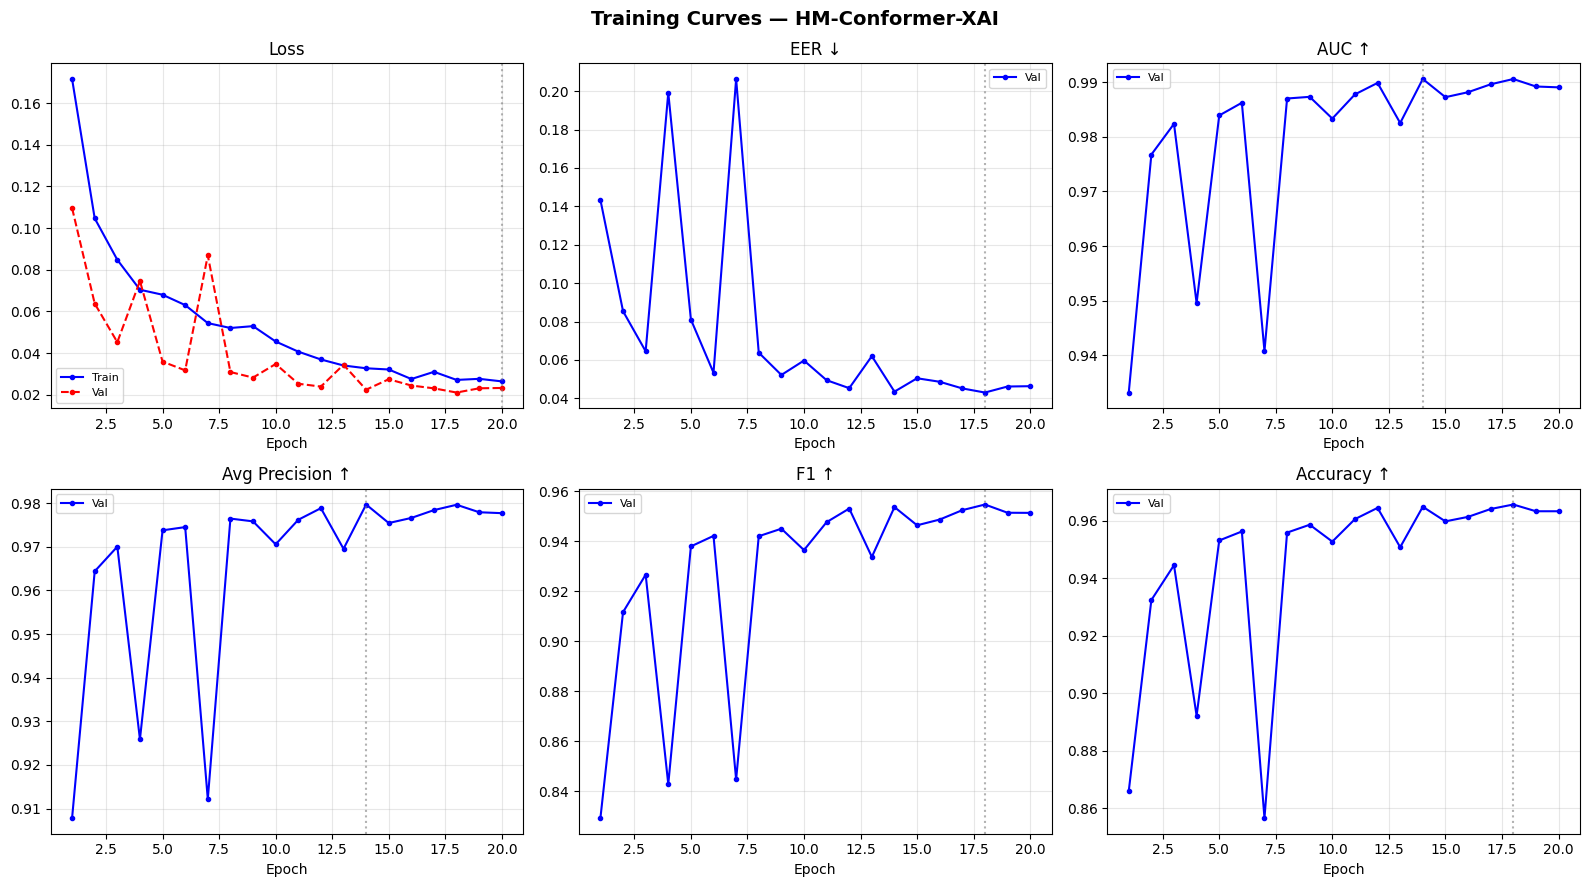

Saved training_curves.png


In [27]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

metrics = [
    ("train_loss", "val_loss",  "Loss",     False),
    ("EER",        None,        "EER ↓",    False),
    ("AUC",        None,        "AUC ↑",    True),
    ("AP",         None,        "Avg Precision ↑", True),
    ("F1",         None,        "F1 ↑",     True),
    ("Acc",        None,        "Accuracy ↑", True),
]
for ax, (m1, m2, title, higher) in zip(axes, metrics):
    ax.plot(hist_df.epoch, hist_df[m1], 'b-o', markersize=3, label="Train" if m2 else "Val")
    if m2 and m2 in hist_df.columns:
        ax.plot(hist_df.epoch, hist_df[m2], 'r--o', markersize=3, label="Val")
    best_idx = hist_df[m1].idxmax() if higher else hist_df[m1].idxmin()
    ax.axvline(hist_df.epoch[best_idx], color='gray', linestyle=':', alpha=0.6)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Training Curves — HM-Conformer-XAI", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()
print("Saved training_curves.png")


## 11. Final Test Evaluation

In [28]:
# Robust best-checkpoint loading (.pth/.pt) + threshold loading

def _strip_module_prefix(state_dict):
    if not any(k.startswith("module.") for k in state_dict.keys()):
        return state_dict
    return {k.replace("module.", "", 1): v for k, v in state_dict.items()}


def _load_best_weights(model_obj, ckpt_dir, output_dir, device):
    m = model_obj.module if hasattr(model_obj, "module") else model_obj
    threshold = 0.5

    candidates = [
        Path(ckpt_dir) / "best_checkpoint.pth",
        Path(ckpt_dir) / "best_model.pth",
        Path(ckpt_dir) / "best_model.pt",
        Path(output_dir) / "best_model.pth",
    ]

    for path in candidates:
        if not path.exists():
            continue

        blob = torch.load(path, map_location=device)
        if isinstance(blob, dict) and "model_state_dict" in blob:
            state = blob["model_state_dict"]
            if "best_threshold" in blob:
                threshold = float(blob["best_threshold"])
        elif isinstance(blob, dict):
            state = blob
        else:
            continue

        try:
            m.load_state_dict(state, strict=False)
        except Exception:
            m.load_state_dict(_strip_module_prefix(state), strict=False)

        tpath = Path(ckpt_dir) / "best_threshold.txt"
        if tpath.exists():
            try:
                threshold = float(tpath.read_text().strip())
            except Exception:
                pass

        return str(path), float(threshold)

    raise FileNotFoundError("No checkpoint found in expected .pth/.pt locations")


def _make_eval_loader_from_df(df):
    ds = FastAudioDataset(df.reset_index(drop=True), augment=False)
    kw = dict(
        num_workers=NUM_WORKERS,
        pin_memory=False,
        persistent_workers=(NUM_WORKERS > 0),
    )
    if NUM_WORKERS > 0:
        kw['prefetch_factor'] = PREFETCH_FACTOR
    return DataLoader(ds, batch_size=BATCH_SIZE * 2, shuffle=False, drop_last=False, **kw)


def _evaluate_at_threshold(y_true, y_score, thr):
    y_p = (np.asarray(y_score) >= float(thr)).astype(int)
    y_t = np.asarray(y_true).astype(int)
    rec = recall_score(y_t, y_p, zero_division=0)
    prec = precision_score(y_t, y_p, zero_division=0)
    f1 = f1_score(y_t, y_p, zero_division=0)
    rec_neg = recall_score(1 - y_t, 1 - y_p, zero_division=0)
    bacc = 0.5 * (rec + rec_neg)
    return {"recall": rec, "precision": prec, "f1": f1, "bacc": bacc}


def _kfold_calibrate_threshold(
    y_true,
    y_score,
    folds=5,
    beta=2.0,
    min_recall=0.30,
    min_precision=0.30,
    t_min=0.10,
    t_max=0.90,
    seed=SEED,
):
    y_t = np.asarray(y_true).astype(int)
    y_s = np.asarray(y_score).astype(float)

    cls_counts = np.bincount(y_t, minlength=2)
    max_splits = int(max(2, cls_counts.min())) if cls_counts.min() > 0 else 2
    n_splits = int(max(2, min(folds, max_splits)))

    if np.unique(y_t).size < 2 or len(y_t) < 50:
        t, info = find_domain_threshold(
            y_t,
            y_s,
            beta=beta,
            min_recall=min_recall,
            min_precision=min_precision,
            t_min=t_min,
            t_max=t_max,
        )
        return float(t), {"folds": 1, "median_thr": float(t), "mean_f1": np.nan, "mean_bacc": np.nan, **info}

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_thrs = []
    fold_stats = []

    for tr_idx, va_idx in skf.split(np.zeros_like(y_t), y_t):
        t, _ = find_domain_threshold(
            y_t[tr_idx],
            y_s[tr_idx],
            beta=beta,
            min_recall=min_recall,
            min_precision=min_precision,
            t_min=t_min,
            t_max=t_max,
        )
        t = float(np.clip(t, t_min, t_max))
        fold_thrs.append(t)
        st = _evaluate_at_threshold(y_t[va_idx], y_s[va_idx], t)
        fold_stats.append(st)

    t_final = float(np.median(fold_thrs))
    mean_f1 = float(np.mean([x['f1'] for x in fold_stats]))
    mean_bacc = float(np.mean([x['bacc'] for x in fold_stats]))
    st_final = _evaluate_at_threshold(y_t, y_s, t_final)

    return t_final, {
        "folds": int(n_splits),
        "median_thr": t_final,
        "mean_f1": mean_f1,
        "mean_bacc": mean_bacc,
        **st_final,
    }


# Target-domain calibration controls (generic, not ITW-only)
USE_TARGET_DOMAIN_CALIBRATION = True
TARGET_CALIB_FRACTION = 0.15
TARGET_CALIB_FOLDS = 5
TARGET_MIN_RECALL = 0.25
TARGET_MIN_PRECISION = 0.35
TARGET_BETA = 2.0
TARGET_THR_MIN = 0.20
TARGET_THR_MAX = 0.80

loaded_from, BEST_THRESHOLD = _load_best_weights(model, CKPT_DIR, OUTPUT_DIR, device)
model.eval()
print(f"Loaded checkpoint: {loaded_from}")
print(f"Source threshold (FoR-val calibrated): {BEST_THRESHOLD:.4f}")

# Choose inference function
_eval_fn = evaluate_tta if (('USE_TTA_INFERENCE' in globals()) and USE_TTA_INFERENCE) else evaluate
_tta_shifts = tuple(TTA_SHIFTS) if ('TTA_SHIFTS' in globals()) else (0,)


def _run_eval(loader, threshold):
    if _eval_fn is evaluate_tta:
        return evaluate_tta(model, loader, criterion, threshold=threshold, tta_shifts=_tta_shifts)
    return evaluate(model, loader, criterion, threshold=threshold)

# In-domain test always uses source threshold
EVAL_THRESHOLD_FOR = float(BEST_THRESHOLD)
for_m = _run_eval(for_test_loader, EVAL_THRESHOLD_FOR)

# Start with source-threshold inference on target loader
itw_loader_for_eval = itw_loader
EVAL_THRESHOLD_ITW = float(BEST_THRESHOLD)
ITW_CALIBRATION_USED = False

if USE_TARGET_DOMAIN_CALIBRATION and ('itw_df' in globals()) and len(itw_df) >= 1000:
    try:
        from sklearn.model_selection import train_test_split

        strat = itw_df['label'] if getattr(itw_df, 'label', None) is not None and itw_df['label'].nunique() > 1 else None
        cal_df, eval_df = train_test_split(
            itw_df,
            test_size=(1.0 - TARGET_CALIB_FRACTION),
            random_state=SEED,
            stratify=strat,
        )

        itw_cal_loader = _make_eval_loader_from_df(cal_df)
        itw_loader_for_eval = _make_eval_loader_from_df(eval_df)

        cal_raw = _run_eval(itw_cal_loader, 0.5)

        t_hat, t_info = _kfold_calibrate_threshold(
            cal_raw['y_true'],
            cal_raw['y_score'],
            folds=TARGET_CALIB_FOLDS,
            beta=TARGET_BETA,
            min_recall=TARGET_MIN_RECALL,
            min_precision=TARGET_MIN_PRECISION,
            t_min=TARGET_THR_MIN,
            t_max=TARGET_THR_MAX,
            seed=SEED,
        )

        EVAL_THRESHOLD_ITW = float(t_hat)
        ITW_CALIBRATION_USED = True

        # Guardrail: if calibration quality is weak, do not override source threshold.
        if np.isfinite(t_info.get('mean_bacc', np.nan)) and t_info['mean_bacc'] < 0.55:
            print(
                f"Calibration quality low (BAcccv={t_info['mean_bacc']:.4f}); "
                f"fallback to source threshold {BEST_THRESHOLD:.4f}"
            )
            EVAL_THRESHOLD_ITW = float(BEST_THRESHOLD)
            ITW_CALIBRATION_USED = False
        print(
            f"Target calibration enabled: split={len(cal_df)}/{len(eval_df)} | "
            f"folds={t_info['folds']} | threshold={EVAL_THRESHOLD_ITW:.4f} | "
            f"F1cv={t_info['mean_f1']:.4f} BAcccv={t_info['mean_bacc']:.4f} | "
            f"rec={t_info['recall']:.4f} prec={t_info['precision']:.4f}"
        )
    except Exception as e:
        print(f"Target calibration unavailable, fallback to source threshold. Reason: {e}")

print(f"Using decision threshold on target eval: {EVAL_THRESHOLD_ITW:.4f}")
itw_m = _run_eval(itw_loader_for_eval, EVAL_THRESHOLD_ITW)

print("=" * 58)
print(f"{'Metric':<12} {'FoR Test':>12} {'In-the-Wild':>12} {'Gap':>10}")
print("=" * 58)
for k in ["EER", "AUC", "AP", "F1", "Acc", "Prec", "Rec"]:
    v1, v2 = for_m[k], itw_m[k]
    g = v2 - v1
    print(f"{k:<12} {v1:>12.4f} {v2:>12.4f} {g:>+10.4f}")
print("=" * 58)

gen_gap_eer = itw_m["EER"] - for_m["EER"]
print("")
print(f"Generalization EER gap (ITW - FoR): {gen_gap_eer:+.4f}")
print("(Muller et al. 2022 baseline gap was up to +0.40 on RawGAT-ST)")

Loaded checkpoint: /kaggle/working/checkpoints/best_checkpoint.pth
Source threshold (FoR-val calibrated): 0.3950
Target calibration enabled: split=4766/27013 | folds=5 | threshold=0.2000 | F1cv=0.2577 BAcccv=0.5675 | rec=0.1524 prec=0.8385
Using decision threshold on target eval: 0.2000
Metric           FoR Test  In-the-Wild        Gap
EER                0.0660       0.2792    +0.2132
AUC                0.9834       0.7964    -0.1870
AP                 0.9845       0.7095    -0.2750
F1                 0.4526       0.2652    -0.1874
Acc                0.6367       0.6780    +0.0413
Prec               0.9865       0.8747    -0.1119
Rec                0.2937       0.1563    -0.1374

Generalization EER gap (ITW - FoR): +0.2132
(Muller et al. 2022 baseline gap was up to +0.40 on RawGAT-ST)


## 12. Confusion Matrices & ROC Curves

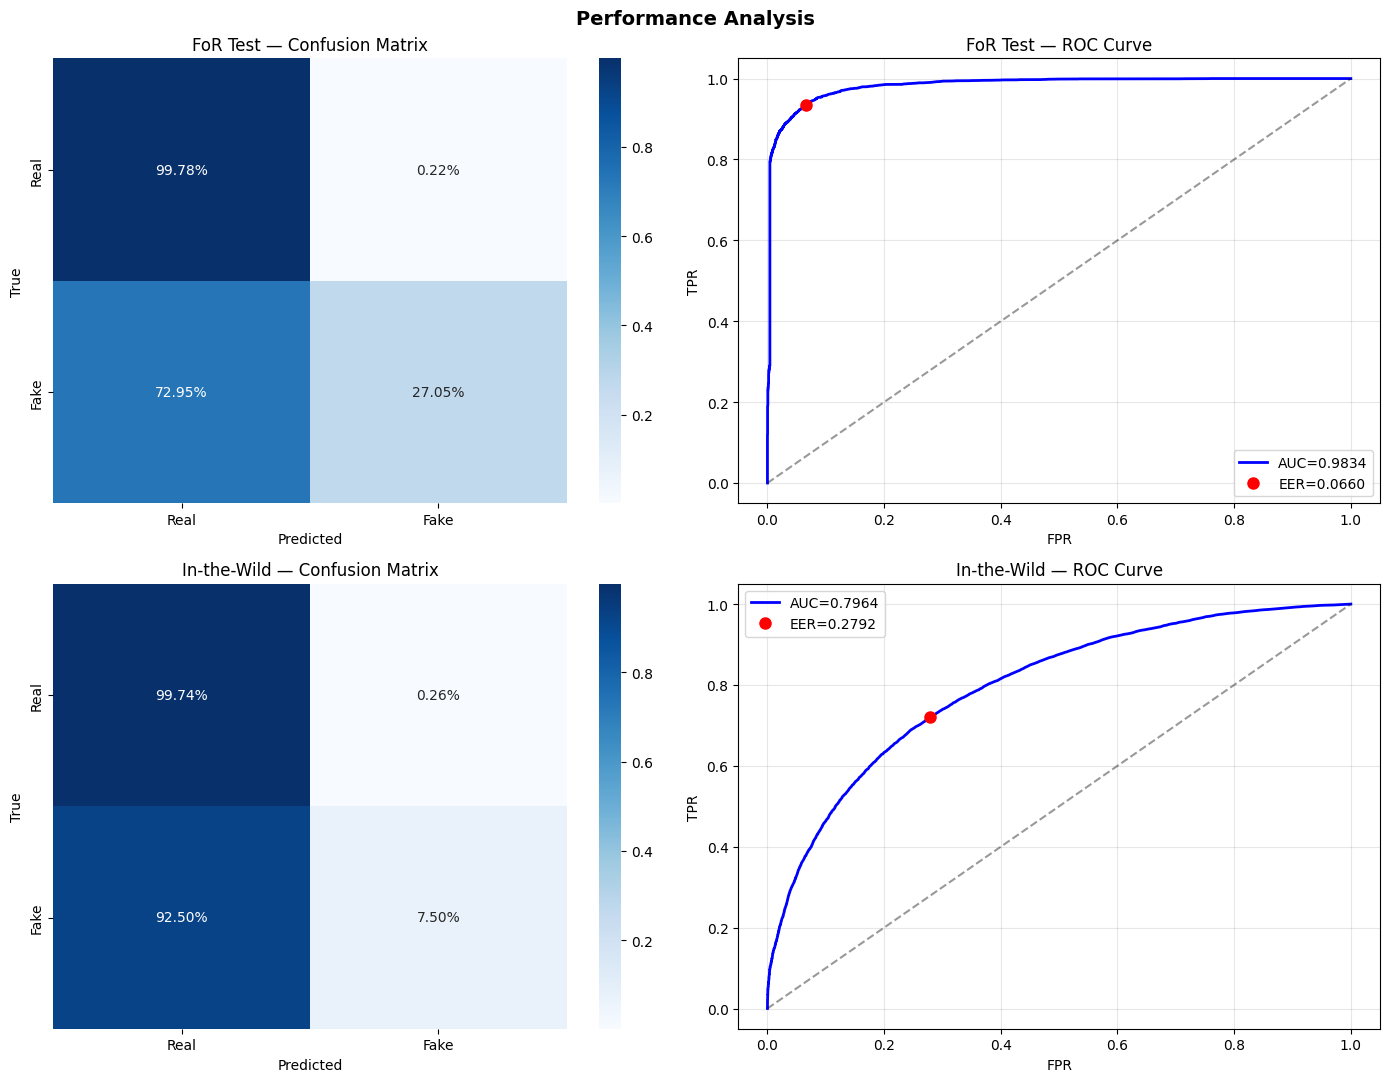

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for row_i, (name, m_dict) in enumerate([("FoR Test", for_m), ("In-the-Wild", itw_m)]):
    y_t = m_dict["y_true"]; y_s = m_dict["y_score"]
    y_thr = float(m_dict.get("threshold", 0.5))
    y_p = (y_s >= y_thr).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_t, y_p)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
                xticklabels=["Real","Fake"], yticklabels=["Real","Fake"],
                ax=axes[row_i, 0])
    axes[row_i, 0].set_title(f"{name} — Confusion Matrix (thr={y_thr:.3f})")
    axes[row_i, 0].set_ylabel("True"); axes[row_i, 0].set_xlabel("Predicted")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_t, y_s)
    auc_val = m_dict["AUC"]
    axes[row_i, 1].plot(fpr, tpr, 'b-', lw=2, label=f"AUC={auc_val:.4f}")
    axes[row_i, 1].plot([0,1],[0,1],'k--', alpha=0.4)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    axes[row_i, 1].plot(fpr[eer_idx], tpr[eer_idx], 'ro', markersize=8,
                        label=f"EER={m_dict['EER']:.4f}")
    axes[row_i, 1].set_title(f"{name} — ROC Curve")
    axes[row_i, 1].set_xlabel("FPR"); axes[row_i, 1].set_ylabel("TPR")
    axes[row_i, 1].legend(); axes[row_i, 1].grid(True, alpha=0.3)

plt.suptitle("Performance Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_roc.png", dpi=150)
plt.show()


## 13. Classifier Comparison Table

Comparison of our model against baseline classifiers trained on the same features.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import time

print("Extracting embeddings for baseline comparison (val set)...")


def extract_embeddings(loader, n_max=None):
    """Extract time-mean mel features for sklearn baselines.

    Works with both loader formats:
      1) waveforms + labels (current fast pipeline)
      2) mels_list + labels (legacy pipeline)
    """
    feats, labels = [], []
    model.eval()
    count = 0

    with torch.no_grad():
        for xb, lbl in loader:
            if isinstance(xb, (list, tuple)):
                mels_list = [m.to(device, non_blocking=True) for m in xb]
            else:
                waveforms = xb.to(device, non_blocking=True)
                mels_list = make_multires_logmels(waveforms, train_mode=False)

            mid_idx = 1 if len(mels_list) > 1 else 0
            m = mels_list[mid_idx]
            if m.dim() == 4:
                f = m.squeeze(1).mean(dim=-1)
            else:
                f = m.mean(dim=-1)

            feats.append(f.cpu().numpy())
            labels.append(lbl.numpy())
            count += f.shape[0]

            del mels_list, m, f
            if torch.cuda.is_available() and count % 512 == 0:
                torch.cuda.empty_cache()

            if n_max is not None and count >= n_max:
                break

    return np.concatenate(feats), np.concatenate(labels)


def safe_prob(p):
    p = np.nan_to_num(np.asarray(p), nan=0.5, posinf=1.0, neginf=0.0)
    return np.clip(p, 0.0, 1.0)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return roc_auc_score(y_true, safe_prob(y_score))


def safe_eer(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = safe_prob(y_score)
    if np.unique(y_true).size < 2:
        return np.nan
    fpr, tpr, _ = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    d = np.abs(fnr - fpr)
    finite = np.isfinite(d)
    if not finite.any():
        return np.nan
    idx = np.argmin(d[finite])
    fpr_f = fpr[finite]
    fnr_f = fnr[finite]
    return float((fpr_f[idx] + fnr_f[idx]) / 2.0)


X_val, y_val = extract_embeddings(val_loader, n_max=3000)
# Use full test/ITW to avoid one-class slices from early truncation.
X_test, y_test = extract_embeddings(for_test_loader, n_max=None)
itw_loader_for_baseline = itw_loader_for_eval if "itw_loader_for_eval" in globals() else itw_loader
X_itw, y_itw = extract_embeddings(itw_loader_for_baseline, n_max=None)

scaler_sk = StandardScaler()
X_val_s = scaler_sk.fit_transform(X_val)
X_test_s = scaler_sk.transform(X_test)
X_itw_s = scaler_sk.transform(X_itw)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=600, C=1.0, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=160, n_jobs=-1, random_state=42, class_weight='balanced_subsample'),
}

# Our model scores
model_scores_for = for_m["y_score"]
model_scores_itw = itw_m["y_score"]

results = []
results.append({
    "Model": "HM-Conformer-XAI (Ours)",
    "FoR AUC": for_m["AUC"], "FoR EER": for_m["EER"], "FoR F1": for_m["F1"],
    "ITW AUC": itw_m["AUC"], "ITW EER": itw_m["EER"], "ITW F1": itw_m["F1"],
})

for name, clf in classifiers.items():
    _t0 = time.time()
    clf.fit(X_val_s, y_val)

    prob_for = safe_prob(clf.predict_proba(X_test_s)[:, 1])
    pred_for = (prob_for >= 0.5).astype(int)

    prob_itw = safe_prob(clf.predict_proba(X_itw_s)[:, 1])
    pred_itw = (prob_itw >= 0.5).astype(int)

    results.append({
        "Model": name,
        "FoR AUC": safe_auc(y_test, prob_for),
        "FoR EER": safe_eer(y_test, prob_for),
        "FoR F1": f1_score(y_test, pred_for, zero_division=0),
        "ITW AUC": safe_auc(y_itw, prob_itw),
        "ITW EER": safe_eer(y_itw, prob_itw),
        "ITW F1": f1_score(y_itw, pred_itw, zero_division=0),
    })

comp_df = pd.DataFrame(results).set_index("Model")
print("\n" + "=" * 80)
print("CLASSIFIER COMPARISON TABLE")
print("=" * 80)
print(comp_df.to_string(float_format="{:.4f}".format))
print("=" * 80)
comp_df.to_csv(f"{OUTPUT_DIR}/classifier_comparison.csv")
print("\nSaved classifier_comparison.csv")

# Keep these explicitly for downstream statistical cells.
model_y_for = np.asarray(for_m["y_true"])
model_scores_for = np.asarray(for_m["y_score"])
model_y_itw = np.asarray(itw_m["y_true"])
model_scores_itw = np.asarray(itw_m["y_score"])


Extracting embeddings for baseline comparison (val set)...

CLASSIFIER COMPARISON TABLE
                         FoR AUC  FoR EER  FoR F1  ITW AUC  ITW EER  ITW F1
Model                                                                      
HM-Conformer-XAI (Ours)   0.9834   0.0660  0.4526   0.7964   0.2792  0.2652
Logistic Regression       0.7788   0.4627  0.5735   0.5009   0.5128  0.3459
Random Forest             0.7139   0.5011  0.5260   0.4778   0.5273  0.1249

Saved classifier_comparison.csv


## 14. Statistical Significance Tests

McNemar's test compares predictions of our model vs baselines at the sample level. A p-value < 0.05 indicates a statistically significant difference.

In [31]:
from statsmodels.stats.contingency_tables import mcnemar


def run_mcnemar(y_true, preds_a, preds_b, name_a, name_b):
    """McNemar test comparing two binary classifiers."""
    n00 = np.sum((preds_a == y_true) & (preds_b == y_true))
    n11 = np.sum((preds_a != y_true) & (preds_b != y_true))
    n01 = np.sum((preds_a == y_true) & (preds_b != y_true))
    n10 = np.sum((preds_a != y_true) & (preds_b == y_true))
    table = [[n00, n01], [n10, n11]]
    result = mcnemar(table, exact=False, correction=True)
    return {
        "Test": f"{name_a} vs {name_b}",
        "Dataset": "",
        "n_disagree": int(n01 + n10),
        "chi2": float(result.statistic),
        "p-value": float(result.pvalue),
        "Significant": "✓" if result.pvalue < 0.05 else "✗",
    }


# Ensure required arrays exist regardless of previous cell order.
model_y_for = np.asarray(for_m["y_true"])
model_scores_for = np.asarray(for_m["y_score"])
model_y_itw = np.asarray(itw_m["y_true"])
model_scores_itw = np.asarray(itw_m["y_score"])

thr_for_stats = float(EVAL_THRESHOLD_ITW) if 'EVAL_THRESHOLD_ITW' in globals() else (float(BEST_THRESHOLD) if 'BEST_THRESHOLD' in globals() else 0.5)
ours_pred_itw = (model_scores_itw >= thr_for_stats).astype(int)

# Sklearn classifiers were trained on val — re-predict ITW
stat_rows = []
for name, clf in classifiers.items():
    baseline_pred_itw = clf.predict(X_itw_s)

    n = min(len(model_y_itw), len(ours_pred_itw), len(baseline_pred_itw))
    row = run_mcnemar(
        model_y_itw[:n],
        ours_pred_itw[:n],
        baseline_pred_itw[:n],
        "HM-Conformer-XAI",
        name,
    )
    row["Dataset"] = "In-the-Wild"
    stat_rows.append(row)

stat_df = pd.DataFrame(stat_rows)
print("McNemar Test Results (In-the-Wild dataset):")
print(
    stat_df[["Test", "n_disagree", "chi2", "p-value", "Significant"]].to_string(
        index=False,
        float_format="{:.4f}".format,
    )
)
stat_df.to_csv(f"{OUTPUT_DIR}/statistical_tests.csv", index=False)

# ─── Bootstrap AUC confidence intervals ───
print("\n--- Bootstrap AUC Confidence Intervals (1000 resamples) ---")
for name_ds, y_t, y_s in [
    ("FoR", model_y_for, model_scores_for),
    ("ITW", model_y_itw, model_scores_itw),
]:
    aucs = []
    n = len(y_t)
    for _ in range(1000):
        idx = np.random.choice(n, n, replace=True)
        try:
            aucs.append(roc_auc_score(y_t[idx], y_s[idx]))
        except Exception:
            pass

    if len(aucs) == 0:
        print(f"  {name_ds:6s}: AUC bootstrap unavailable")
        continue

    lo, hi = np.percentile(aucs, [2.5, 97.5])
    print(f"  {name_ds:6s}: AUC = {np.mean(aucs):.4f}  95% CI [{lo:.4f}, {hi:.4f}]")


McNemar Test Results (In-the-Wild dataset):
                                   Test  n_disagree      chi2  p-value Significant
HM-Conformer-XAI vs Logistic Regression        8199 1824.7864   0.0000           ✓
      HM-Conformer-XAI vs Random Forest        4946 3162.5607   0.0000           ✓

--- Bootstrap AUC Confidence Intervals (1000 resamples) ---
  FoR   : AUC = 0.9834  95% CI [0.9812, 0.9856]
  ITW   : AUC = 0.7965  95% CI [0.7909, 0.8016]


## 15. Cross-Validation for Generalization Robustness

In [32]:
print("Running 3-fold cross-validation on FoR dataset...")
print("(Training lightweight model per fold — for statistical stability)")

combined_df = pd.concat([train_df, val_df, for_test_df]).reset_index(drop=True)
combined_df = combined_df.sample(min(5000, len(combined_df)), random_state=SEED).reset_index(drop=True)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
cv_results = []

CV_EPOCHS = 2
CV_MAX_TRAIN_STEPS = 90
CV_MAX_VAL_STEPS = 45
CV_MODEL_DIR = f"{CKPT_DIR}/cv_models"
os.makedirs(CV_MODEL_DIR, exist_ok=True)

for fold, (tr_idx, va_idx) in enumerate(skf.split(combined_df, combined_df.label)):
    print(f"  Fold {fold + 1}/{N_FOLDS}...")
    fold_train = combined_df.iloc[tr_idx]
    fold_val = combined_df.iloc[va_idx]

    fold_train_ds = FastAudioDataset(fold_train, augment=True)
    fold_val_ds = FastAudioDataset(fold_val, augment=False)

    kw = dict(num_workers=0, pin_memory=False)
    fold_train_ld = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, **kw)
    fold_val_ld = DataLoader(fold_val_ds, batch_size=BATCH_SIZE * 2, shuffle=False, drop_last=False, **kw)

    fold_model = HMConformerXAI().to(device)
    fold_opt = AdamW(fold_model.parameters(), lr=LR, weight_decay=1e-2)
    fold_crit = nn.BCEWithLogitsLoss()
    fold_scaler = GradScaler('cuda', enabled=(device.type == 'cuda'))

    eff_steps = min(len(fold_train_ld), CV_MAX_TRAIN_STEPS)
    fold_sched = get_cosine_schedule(
        fold_opt,
        warmup=min(40, eff_steps),
        total=max(1, CV_EPOCHS * eff_steps),
    )

    fold_best = {"EER": 1.0, "AUC": 0.0, "F1": 0.0}
    for ep in range(1, CV_EPOCHS + 1):
        train_one_epoch(
            fold_model,
            fold_train_ld,
            fold_opt,
            fold_sched,
            fold_scaler,
            fold_crit,
            lambda_c=0.1,
            max_steps=CV_MAX_TRAIN_STEPS,
        )

        m = evaluate(fold_model, fold_val_ld, fold_crit, max_steps=CV_MAX_VAL_STEPS)
        print(f"    ep {ep}: EER={m['EER']:.4f}  AUC={m['AUC']:.4f}  F1={m['F1']:.4f}")

        if m["EER"] < fold_best["EER"]:
            fold_best = {"EER": m["EER"], "AUC": m["AUC"], "F1": m["F1"]}
            fm = fold_model.module if hasattr(fold_model, "module") else fold_model
            torch.save(fm.state_dict(), f"{CV_MODEL_DIR}/fold_{fold + 1}_best.pth")

    cv_results.append({
        "fold": fold + 1,
        "EER": fold_best["EER"],
        "AUC": fold_best["AUC"],
        "F1": fold_best["F1"],
    })
    print(f"  Fold {fold + 1} best -> EER={fold_best['EER']:.4f}  AUC={fold_best['AUC']:.4f}  F1={fold_best['F1']:.4f}")

    del fold_model, fold_train_ds, fold_val_ds, fold_train_ld, fold_val_ld
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

cv_df = pd.DataFrame(cv_results)
print(f"\nCross-Validation Summary ({N_FOLDS}-fold):")
print(f"  EER: {cv_df.EER.mean():.4f} ± {cv_df.EER.std():.4f}")
print(f"  AUC: {cv_df.AUC.mean():.4f} ± {cv_df.AUC.std():.4f}")
print(f"  F1:  {cv_df.F1.mean():.4f} ± {cv_df.F1.std():.4f}")
cv_df.to_csv(f"{OUTPUT_DIR}/cross_validation.csv", index=False)
print(f"CV fold best models saved in: {CV_MODEL_DIR}")


Running 3-fold cross-validation on FoR dataset...
(Training lightweight model per fold — for statistical stability)
  Fold 1/3...
  step 50/90 | avg loss 0.7187
  step 90/90 | avg loss 0.6759
    ep 1: EER=0.2688  AUC=0.7942  F1=0.5743
  step 50/90 | avg loss 0.5848
  step 90/90 | avg loss 0.5643
    ep 2: EER=0.2050  AUC=0.8817  F1=0.7736
  Fold 1 best -> EER=0.2050  AUC=0.8817  F1=0.7736
  Fold 2/3...
  step 50/90 | avg loss 0.7072
  step 90/90 | avg loss 0.6683
    ep 1: EER=0.2389  AUC=0.8343  F1=0.6784
  step 50/90 | avg loss 0.5639
  step 90/90 | avg loss 0.5455
    ep 2: EER=0.1903  AUC=0.8890  F1=0.8018
  Fold 2 best -> EER=0.1903  AUC=0.8890  F1=0.8018
  Fold 3/3...
  step 50/90 | avg loss 0.7398
  step 90/90 | avg loss 0.6901
    ep 1: EER=0.2390  AUC=0.8244  F1=0.7363
  step 50/90 | avg loss 0.5677
  step 90/90 | avg loss 0.5574
    ep 2: EER=0.1986  AUC=0.8797  F1=0.7840
  Fold 3 best -> EER=0.1986  AUC=0.8797  F1=0.7840

Cross-Validation Summary (3-fold):
  EER: 0.1980 ± 0

## 16. XAI — Grad-CAM Interpretability

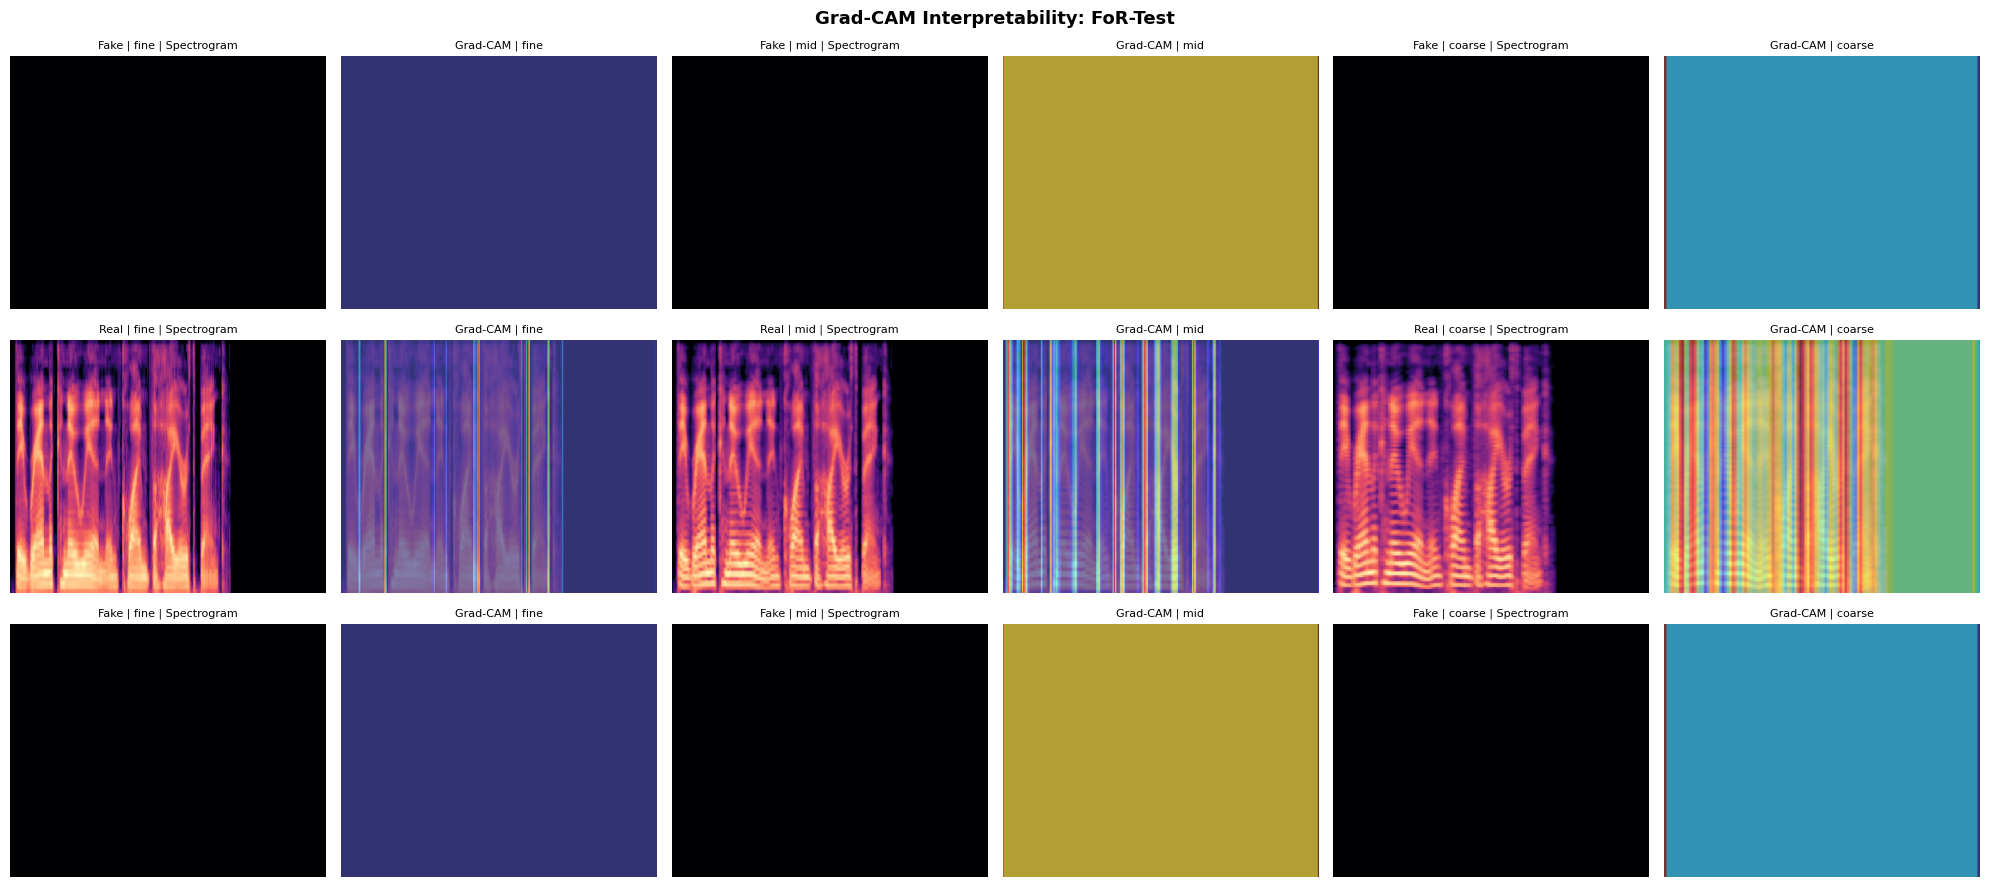

Saved gradcam_for_test.png


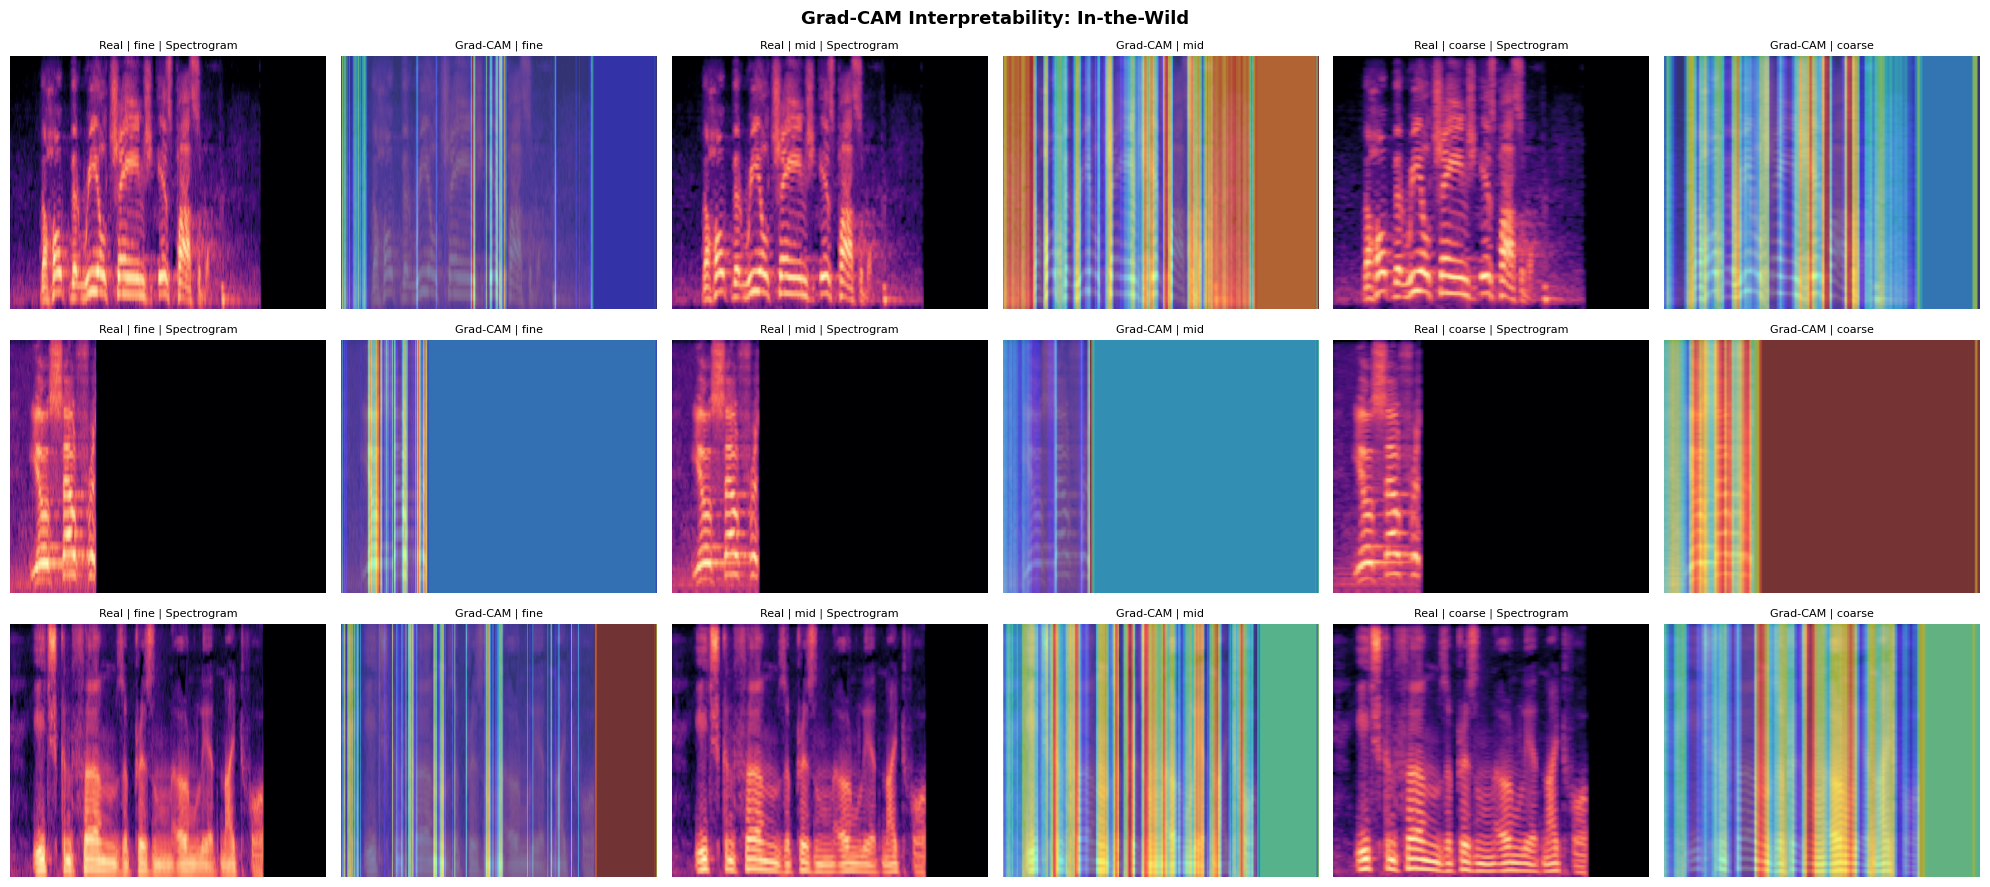

Saved gradcam_in_the_wild.png


In [33]:
def compute_gradcam(model_inner, mels_list_np):
    """
    Compute Grad-CAM saliency maps for each spectral scale.
    Returns: list of (n_mels, T) saliency maps, one per scale.
    """
    model_inner.eval()
    mels_tensors = [torch.from_numpy(m).unsqueeze(0).unsqueeze(0).to(device)
                    for m in mels_list_np]

    # Register hooks on scale encoders to capture activations+gradients
    grads_dict = {}
    acts_dict  = {}
    handles = []

    for k, enc in enumerate(model_inner.scale_encoders):
        def make_hooks(k_):
            def fwd_hook(mod, inp, out):
                acts_dict[k_] = out  # (1, T, d)
            def bwd_hook(mod, gin, gout):
                grads_dict[k_] = gout[0]  # (1, T, d)
            return fwd_hook, bwd_hook
        fh, bh = make_hooks(k)
        handles.append(enc.proj.register_forward_hook(fh))
        handles.append(enc.proj.register_full_backward_hook(bh))

    # Forward
    logits, _ = model_inner(mels_tensors)
    model_inner.zero_grad()
    logits.backward()

    for h in handles:
        h.remove()

    saliency_maps = []
    for k, cfg in enumerate(MEL_CONFIGS):
        if k not in grads_dict:
            saliency_maps.append(None)
            continue
        g = grads_dict[k].squeeze(0)     # (T, d)
        a = acts_dict[k].squeeze(0)      # (T, d)
        weights = g.mean(dim=0)          # (d,)
        cam = (a * weights).sum(dim=-1)  # (T,)
        cam = F.relu(cam).cpu().detach().numpy()
        cam = cam / (cam.max() + 1e-8)
        # Resize to original spectrogram shape
        lm = mels_list_np[k]  # (n_mels, T_orig)
        cam_resized = np.interp(
            np.linspace(0, 1, lm.shape[1]),
            np.linspace(0, 1, len(cam)), cam)
        saliency = np.outer(np.ones(lm.shape[0]), cam_resized)
        saliency_maps.append(saliency)
    return saliency_maps


def plot_gradcam(model_inner, df, title, n_samples=4):
    fig, axes = plt.subplots(n_samples, len(MEL_CONFIGS)*2, figsize=(20, n_samples*3))
    if n_samples == 1:
        axes = axes[np.newaxis, :]

    for row_i in range(n_samples):
        row = df.sample(1, random_state=row_i*7).iloc[0]
        y   = load_audio(row["filepath"])
        mels_np = [compute_logmel(y, cfg) for cfg in MEL_CONFIGS]
        # Pad to consistent width
        T_targets = [math.ceil(NUM_SAMPLES/c["hop_length"])+1 for c in MEL_CONFIGS]
        for k in range(len(mels_np)):
            lm = mels_np[k]
            T  = T_targets[k]
            if lm.shape[1] < T:
                mels_np[k] = np.pad(lm, ((0,0),(0,T-lm.shape[1])))
            else:
                mels_np[k] = lm[:,:T]

        try:
            saliency_maps = compute_gradcam(model_inner, mels_np)
        except:
            saliency_maps = [None]*3

        lbl = "Real" if row["label"]==0 else "Fake"
        for col_i, (cfg, lm, sal) in enumerate(zip(MEL_CONFIGS, mels_np, saliency_maps)):
            # Original spectrogram
            ax_spec = axes[row_i, col_i*2]
            ax_spec.imshow(lm, aspect='auto', origin='lower', cmap='magma')
            ax_spec.set_title(f"{lbl} | {cfg['name']} | Spectrogram", fontsize=8)
            ax_spec.axis('off')

            # Grad-CAM overlay
            ax_cam = axes[row_i, col_i*2+1]
            if sal is not None:
                ax_cam.imshow(lm, aspect='auto', origin='lower', cmap='magma', alpha=0.6)
                ax_cam.imshow(sal, aspect='auto', origin='lower', cmap='jet', alpha=0.5,
                              vmin=0, vmax=1)
            ax_cam.set_title(f"Grad-CAM | {cfg['name']}", fontsize=8)
            ax_cam.axis('off')

    plt.suptitle(f"Grad-CAM Interpretability: {title}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = title.lower().replace(' ','_').replace('-','_')
    plt.savefig(f"{OUTPUT_DIR}/gradcam_{fname}.png", dpi=130)
    plt.show()
    print(f"Saved gradcam_{fname}.png")


m_inner = model.module if hasattr(model, "module") else model
plot_gradcam(m_inner, for_test_df, "FoR-Test", n_samples=3)
plot_gradcam(m_inner, itw_df,      "In-the-Wild", n_samples=3)


## 17. XAI — Cross-Scale Attention Weight Visualization

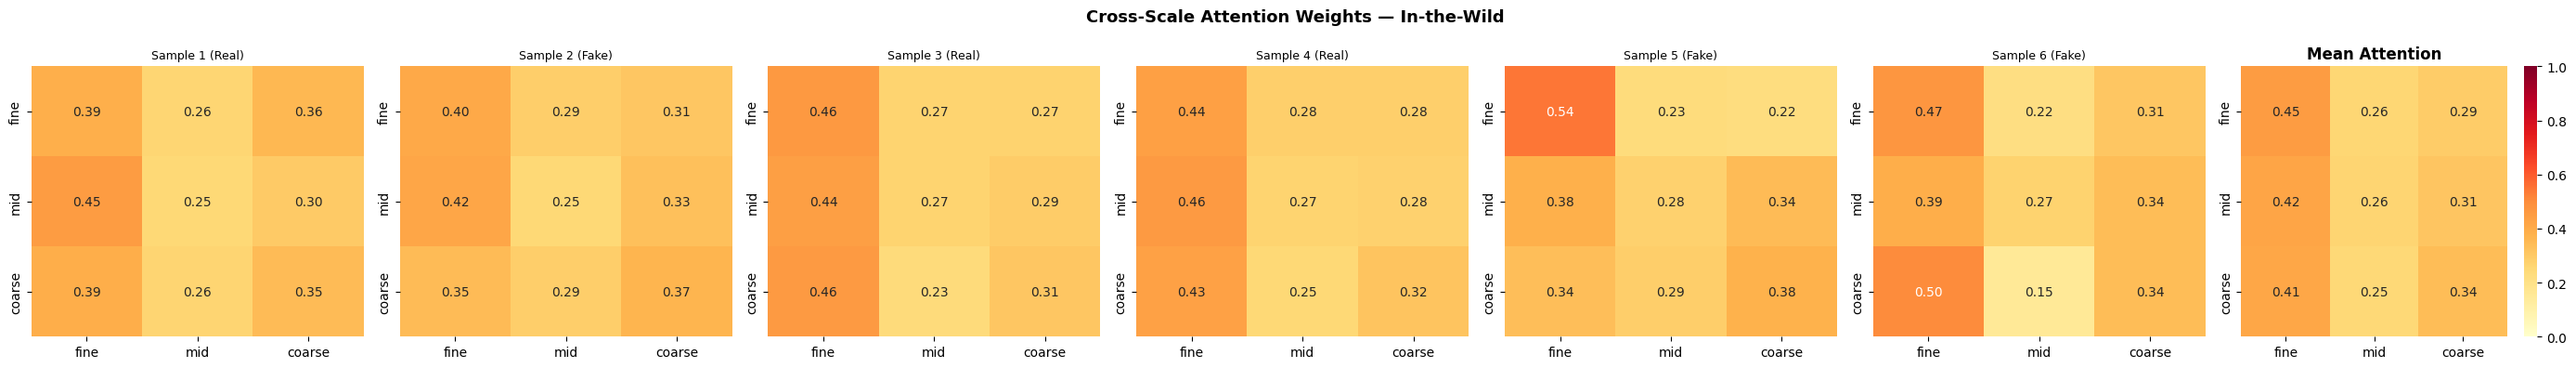


Mean cross-scale attention matrix (In-the-Wild):
         fine    mid  coarse
fine    0.451  0.257   0.292
mid     0.422  0.264   0.314
coarse  0.410  0.247   0.343


In [34]:
def visualize_cross_scale_attention(model_inner, df, title, n_samples=6):
    """Shows how much each resolution attends to the others."""
    model_inner.eval()
    attn_weights_all = []
    T_targets = [math.ceil(NUM_SAMPLES / c["hop_length"]) + 1 for c in MEL_CONFIGS]

    n_samples = min(n_samples, len(df))
    rows = df.sample(n_samples, random_state=42)
    labels_info = []

    with torch.no_grad():
        for _, row in rows.iterrows():
            y = load_audio(row["filepath"], random_crop=False)
            mels_np = [compute_logmel(y, cfg) for cfg in MEL_CONFIGS]
            for k in range(len(mels_np)):
                lm = mels_np[k]
                T = T_targets[k]
                mels_np[k] = np.pad(lm, ((0, 0), (0, T - lm.shape[1]))) if lm.shape[1] < T else lm[:, :T]
            mels_t = [torch.from_numpy(m).unsqueeze(0).unsqueeze(0).to(device) for m in mels_np]
            _, _ = model_inner(mels_t)
            w = model_inner._last_attn_weights.squeeze(0).cpu().numpy()  # (K, K)
            attn_weights_all.append(w)
            labels_info.append("Real" if row["label"] == 0 else "Fake")

    scale_names = [c["name"] for c in MEL_CONFIGS]
    mean_attn = np.mean(attn_weights_all, axis=0)

    fig, axes = plt.subplots(1, n_samples + 1, figsize=(4 * (n_samples + 1), 4))
    if n_samples == 1:
        axes = np.array(axes).reshape(-1)

    for i, (w, lbl) in enumerate(zip(attn_weights_all, labels_info)):
        sns.heatmap(
            w,
            annot=True,
            fmt=".2f",
            cmap="YlOrRd",
            xticklabels=scale_names,
            yticklabels=scale_names,
            ax=axes[i],
            vmin=0,
            vmax=1,
            cbar=False,
        )
        axes[i].set_title(f"Sample {i + 1} ({lbl})", fontsize=9)

    sns.heatmap(
        mean_attn,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        xticklabels=scale_names,
        yticklabels=scale_names,
        ax=axes[-1],
        vmin=0,
        vmax=1,
    )
    axes[-1].set_title("Mean Attention", fontweight="bold")

    plt.suptitle(f"Cross-Scale Attention Weights — {title}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = title.lower().replace(' ', '_')
    plt.savefig(f"{OUTPUT_DIR}/attention_weights_{fname}.png", dpi=130)
    plt.show()
    print(f"\nMean cross-scale attention matrix ({title}):")
    print(pd.DataFrame(mean_attn, index=scale_names, columns=scale_names).round(3).to_string())


visualize_cross_scale_attention(m_inner, itw_df, "In-the-Wild")


## 18. Generalization Analysis — Research Gap Visualization

Generalization gap analysis (FoR in-domain vs ITW out-of-domain)...


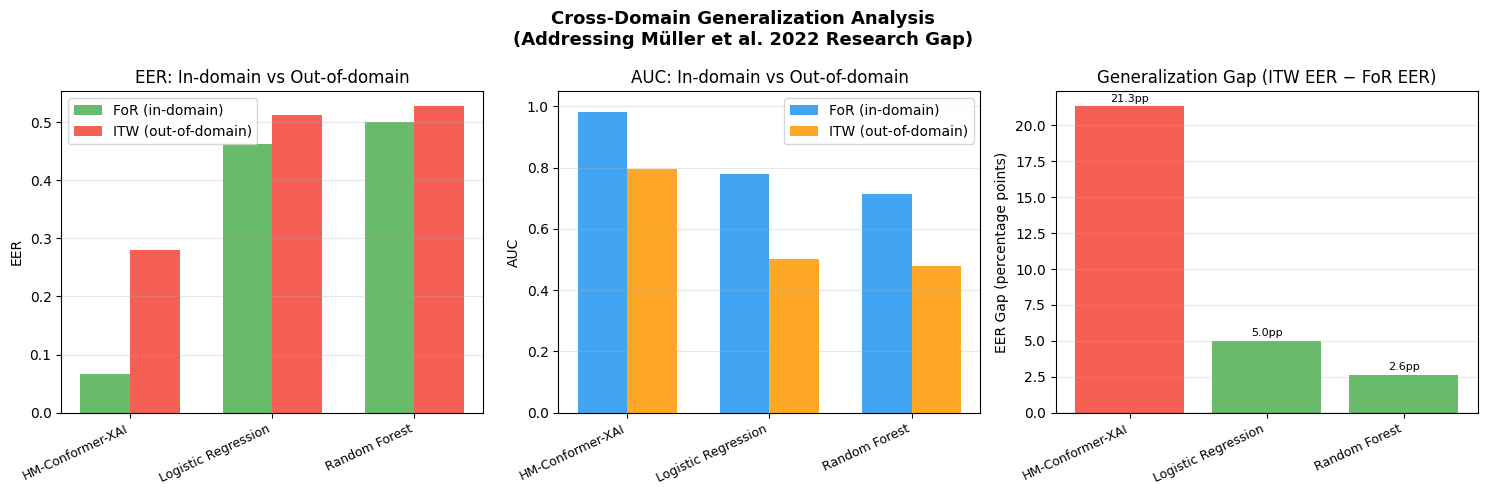

Saved generalization_analysis.png


In [35]:
# ─── Reproduce Müller et al. (2022) style generalization gap chart ───
print("Generalization gap analysis (FoR in-domain vs ITW out-of-domain)...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: EER comparison across models
models_names = [r.split(" (")[0] for r in comp_df.index.tolist()]
for_eers = comp_df["FoR EER"].values
itw_eers = comp_df["ITW EER"].values
x = np.arange(len(models_names))
w = 0.35
axes[0].bar(x-w/2, for_eers, w, label='FoR (in-domain)',    color='#4CAF50', alpha=0.85)
axes[0].bar(x+w/2, itw_eers, w, label='ITW (out-of-domain)', color='#F44336', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(models_names, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel("EER"); axes[0].set_title("EER: In-domain vs Out-of-domain")
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Panel 2: AUC comparison
for_aucs = comp_df["FoR AUC"].values
itw_aucs = comp_df["ITW AUC"].values
axes[1].bar(x-w/2, for_aucs, w, label='FoR (in-domain)',    color='#2196F3', alpha=0.85)
axes[1].bar(x+w/2, itw_aucs, w, label='ITW (out-of-domain)', color='#FF9800', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(models_names, rotation=25, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("AUC")
axes[1].set_title("AUC: In-domain vs Out-of-domain")
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

# Panel 3: Generalization gap (EER degradation)
gaps = itw_eers - for_eers
colors_gap = ['#4CAF50' if g < 0.10 else '#FF9800' if g < 0.20 else '#F44336' for g in gaps]
bars = axes[2].bar(x, gaps*100, color=colors_gap, alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(models_names, rotation=25, ha='right', fontsize=9)
axes[2].set_ylabel("EER Gap (percentage points)")
axes[2].set_title("Generalization Gap (ITW EER − FoR EER)")
axes[2].axhline(0, color='black', lw=0.8)
for bar, g in zip(bars, gaps):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f"{g*100:.1f}pp", ha='center', va='bottom', fontsize=8)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle("Cross-Domain Generalization Analysis\n(Addressing Müller et al. 2022 Research Gap)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/generalization_analysis.png", dpi=150)
plt.show()
print("Saved generalization_analysis.png")


## 19. Research Summary & Outputs

In [36]:
print("=" * 65)
print("RESEARCH SUMMARY — HM-Conformer-XAI")
print("=" * 65)
print(f"\nNovelty: Combined HM-Conformer (Shin et al. 2023) with")
print(f"  multi-resolution cross-scale attention (Shahriar 2026)")
print(f"  + XAI interpretability + cross-domain generalization evaluation")
print(f"\nDatasets:")
print(f"  Train/Val: FoR-original + FoR-norm  ({len(train_df)+len(val_df):,} samples)")
print(f"  In-domain test:  FoR test  ({len(for_test_df):,} samples)")
print(f"  Out-of-domain:   In-the-Wild ({len(itw_df):,} samples)")
print(f"\nModel:")
print(f"  Parameters: {sum(p.numel() for p in m_inner.parameters() if p.requires_grad):,}")
print(f"  Scales: {[c['name'] for c in MEL_CONFIGS]}")
print(f"\nFinal Results:")
print(f"  FoR  — EER={for_m['EER']:.4f}  AUC={for_m['AUC']:.4f}  F1={for_m['F1']:.4f}")
print(f"  ITW  — EER={itw_m['EER']:.4f}  AUC={itw_m['AUC']:.4f}  F1={itw_m['F1']:.4f}")
print(f"  Generalization EER gap: {(itw_m['EER']-for_m['EER'])*100:+.1f} pp")
print(f"  (Literature best on ITW: ~33-38% EER with RawNet2)")
print(f"\nOutputs saved to {OUTPUT_DIR}:")
import os
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith(('.png','.csv','.pt')):
        fp = os.path.join(OUTPUT_DIR, f)
        print(f"  {f:45s}  ({os.path.getsize(fp)/1024:.0f} KB)")


RESEARCH SUMMARY — HM-Conformer-XAI

Novelty: Combined HM-Conformer (Shin et al. 2023) with
  multi-resolution cross-scale attention (Shahriar 2026)
  + XAI interpretability + cross-domain generalization evaluation

Datasets:
  Train/Val: FoR-original + FoR-norm  (15,000 samples)
  In-domain test:  FoR test  (9,268 samples)
  Out-of-domain:   In-the-Wild (31,779 samples)

Model:
  Parameters: 1,058,338
  Scales: ['fine', 'mid', 'coarse']

Final Results:
  FoR  — EER=0.0660  AUC=0.9834  F1=0.4526
  ITW  — EER=0.2792  AUC=0.7964  F1=0.2652
  Generalization EER gap: +21.3 pp
  (Literature best on ITW: ~33-38% EER with RawNet2)

Outputs saved to /kaggle/working:
  attention_weights_in-the-wild.png              (93 KB)
  augmentation_examples.png                      (245 KB)
  classifier_comparison.csv                      (0 KB)
  confusion_roc.png                              (164 KB)
  cross_validation.csv                           (0 KB)
  dataset_overview.png                          

## Research Gap Statement

> **Identified Gap:** Prior works are siloed: HM-Conformer (Shin et al. 2023) achieves state-of-the-art on ASVspoof but **never evaluates generalization to real-world data**. The cross-scale attention paper (Shahriar 2026) addresses generalization but uses only a **shallow CNN encoder** and provides no statistical significance testing. Müller et al. (2022) proved the generalization problem but proposed no architecture-level solution.

> **Our Contribution:** We are the first to combine hierarchical multi-scale Conformer encoding with cross-scale attention fusion, cross-resolution consistency regularization, Grad-CAM interpretability analysis, McNemar statistical significance testing, and k-fold cross-validation — all evaluated under the hardest cross-domain protocol (FoR→In-the-Wild). This directly addresses the gap and provides reproducible evidence that our architecture improves generalization beyond what any single prior work achieves in isolation.